<a href="https://colab.research.google.com/github/SvitLanaTy/MW_Ripetibilita/blob/main/Mammowave_Ripetibilita_Analysis_CORRETTO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MammoWave — Analisi Ripetibilità (DATASET CORRETTO)
### Versione con flag qualità aggiornati, età corrette, e ruolo coppa corretto per 800X

**Correzioni applicate:**
- 🆕 **100X**: aggiunto flag `MOVIMENTO_LIEVE` su Fase 1 seno SX (piccolo movimento braccio durante misura DX al 98%, non escluso)
- 🔄 **800X**: i 3 eventi precedentemente classificati `MOVIMENTO` (esclusi) sono ora `MOVIMENTO_INTERVALLO` — il movimento è avvenuto durante il riposizionamento delle antenne tra acq1 e acq2, **non durante l'acquisizione** → **dati ripristinati, non più esclusi**
- 🔄 **800X**: la coppa "Base" reale è la II (non la I) — abbiamo iniziato con "Base-1". Cup_Role ricalcolato solo per questa paziente
- 🔄 **Età corrette**: 200X 65→**46** anni · 400X 63→**64** anni
- 🆕 **Nuova analisi**: confronto Coppa Base (corretta) vs Coppa III teflon






## 1. Installazione librerie e mount Google Drive

In [ ]:
!pip install openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, wilcoxon, spearmanr, shapiro
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print("✅ Librerie caricate correttamente")

✅ Librerie caricate correttamente


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print("✅ Google Drive montato")

Mounted at /content/drive
✅ Google Drive montato


In [ ]:
FILE_PATH  = "/content/drive/MyDrive/data/rep/TEST-RIPETIBILITA_local_measurements.xlsx"
OUTPUT_DIR = "/content/drive/MyDrive/data/rep/output_cor"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"📂 Output directory: {OUTPUT_DIR}")

📂 Output directory: /content/drive/MyDrive/data/rep/output_cor


## 2. Caricamento, pulizia dati e ricodifica pazienti


In [ ]:
df = pd.read_excel(FILE_PATH)
print(f"📊 Dataset caricato: {df.shape[0]} righe × {df.shape[1]} colonne")
df.head(3)

📊 Dataset caricato: 180 righe × 11 colonne


,Patient,Fase,Breast,Mis.,Cup,Examination date,max_n,max2avg,var_p,mad_p,var_r
0,1000,1,LEFT,Tg.IV,II,2026-01-13 09:25:25.576,0.779476,2.586944,0.102585,0.242926,0.828048
1,1000,1,LEFT,Tg.IV,II,2026-01-13 09:14:26.110,0.577395,1.961391,0.029818,0.146383,0.264721
2,1000,1,RIGHT,Tg.IV,II,2026-01-13 09:03:25.598,0.885216,2.996218,0.174122,0.254043,1.301305


In [ ]:
# ── PULIZIA E NORMALIZZAZIONE ──────────────────────────────────────────────
METRICS = ["max_n", "max2avg", "var_p", "mad_p", "var_r"]

mis_map = {
    "Tg II":"Tg.II", "Tg. II":"Tg.II", "Tg.II":"Tg.II",
    "Tg.IV":"Tg.IV", "Tg. IV":"Tg.IV",
    "Tg.III":"Tg.III", "Tg.III ":"Tg.III",
    "tg. IIIc":"Tg.IIIc",
}
df["Mis_norm"] = df["Mis."].str.strip().map(lambda x: mis_map.get(x, x))

# ── Ricodifica pazienti ──────────────────────────────────────────────────
pat_recode = {
    1000:"100X", 2000:"200X", 3000:"300X",
    4000:"400X", 5000:"500X", 6000:"600X",
    7000:"700X", 8000:"800X", 9000:"900X",
}
df["Patient_orig"] = df["Patient"].copy()
df["Patient"]      = df["Patient"].map(pat_recode)

# ── ETÀ CORRETTE ──────────────────────────────────────────────────────────
# 200X: 65 → 46 anni (corretto)
# 400X: 63 → 64 anni (corretto)
age_map = {
    "100X": 56, "200X": 46, "300X": 68, "400X": 64, "500X": 54,
    "600X": 43, "700X": 64, "800X": 47, "900X": 53,
}
df["Eta"] = df["Patient"].map(age_map)

# ── Colonne strutturali ───────────────────────────────────────────────────
df["Examination date"] = pd.to_datetime(df["Examination date"])
df = df.sort_values(["Patient","Fase","Breast","Examination date"]).reset_index(drop=True)

pair_counts = df.groupby(["Patient","Fase","Breast"]).size().reset_index(name="pair_count")
df = df.merge(pair_counts, on=["Patient","Fase","Breast"])
df["coppia_completa"] = df["pair_count"] == 2
df["Sessione"]        = df["Fase"].apply(lambda x: "A" if x % 2 == 1 else "B")

# ── CUP_ROLE con override per 800X ────────────────────────────────────────
# Standard: Fase1-2=Base, Fase3-4=Base+1, Fase5-6=Base+2
# 800X: la coppa "base" REALE è la II, ma abbiamo iniziato con "base-1" (cup I)
#   → Fase1-2=Base-1 (cup I), Fase3-4=Base (cup II vero), Fase5-6=Base+1 (teflon)
default_role_map  = {1:"Base",2:"Base",3:"Base+1",4:"Base+1",5:"Base+2",6:"Base+2",7:"Extra"}
p800x_role_map    = {1:"Base-1",2:"Base-1",3:"Base",4:"Base",5:"Base+1",6:"Base+1",7:"Extra"}

def get_cup_role(patient, fase):
    if patient == "800X":
        return p800x_role_map.get(fase, "Extra")
    return default_role_map.get(fase, "Extra")

df["Cup_Role"] = df.apply(lambda r: get_cup_role(r["Patient"], r["Fase"]), axis=1)
df["Acq_n"]    = df.groupby(["Patient","Fase","Breast"]).cumcount() + 1

print("✅ Pulizia, ricodifica ed età corrette completate")
print(f"   Età pazienti: {age_map}")
print(f"   Cup_Role per 800X (override): {p800x_role_map}")
print(f"   Acquisizioni totali: {len(df)}")

✅ Pulizia, ricodifica ed età corrette completate
   Età pazienti: {'100X': 56, '200X': 46, '300X': 68, '400X': 64, '500X': 54, '600X': 43, '700X': 64, '800X': 47, '900X': 53}
   Cup_Role per 800X (override): {1: 'Base-1', 2: 'Base-1', 3: 'Base', 4: 'Base', 5: 'Base+1', 6: 'Base+1', 7: 'Extra'}
   Acquisizioni totali: 180


## 3. Flag qualità — annotazione eventi clinici (CORRETTI)

Flag aggiornati rispetto alla versione precedente:

| Flag | Significato | Causa esclusione? |
|---|---|---|
| `NO_CAMERA` | Posizionamento senza telecamera | No |
| `MOVIMENTO` | Movimento confermato **durante** l'acquisizione | **Sì** |
| 🆕 `MOVIMENTO_LIEVE` | Movimento minimo, effetto trascurabile | No |
| 🆕 `MOVIMENTO_INTERVALLO` | Movimento avvenuto **tra** acq1 e acq2 durante homing antenne, non durante la scansione | No |
| `INCOMPLETA` | Una sola misura invece di 2 | Sì (non è una coppia valida) |
| `ORDINE_INV` | Fasi eseguite in ordine invertito | No (corretto, non escluso) |
| `OK` | Nessun problema | — |


In [ ]:
# ── DIZIONARIO FLAG QUALITÀ — VERSIONE CORRETTA ─────────────────────────────
FLAGS = {
    # ── P100X: telecamera non funzionante fasi 1-4 ─────────────────────────
    ("100X", 1, None,    None): "NO_CAMERA",
    ("100X", 2, None,    None): "NO_CAMERA",
    ("100X", 3, None,    None): "NO_CAMERA",
    ("100X", 4, None,    None): "NO_CAMERA+INCOMPLETA",
    # 🆕 CORREZIONE: Fase1 prima misura DX al 98%, piccolo movimento braccio SX
    #    sposta lievemente il seno SX. Impatta le acquisizioni SX della Fase 1
    #    (eseguite dopo la DX nella sequenza DX,DX,SX,SX). Effetto trascurabile.
    ("100X", 1, "LEFT",  None): "NO_CAMERA+MOVIMENTO_LIEVE",

    # ── P200X ────────────────────────────────────────────────────────────
    ("200X", 1, "LEFT",  None): "NO_CAMERA",
    ("200X", 4, "RIGHT", None): "NO_CAMERA",
    ("200X", 5, "LEFT",  2   ): "MOVIMENTO",   # confermato durante acquisizione

    # ── P300X ────────────────────────────────────────────────────────────
    ("300X", 1, None,    None): "NO_CAMERA",
    ("300X", 2, None,    None): "NO_CAMERA",
    ("300X", 5, "LEFT",  None): "NO_CAMERA",

    # ── P500X: ordine fasi 5-6 invertito ────────────────────────────────
    ("500X", 5, None,    None): "ORDINE_INV",
    ("500X", 6, None,    None): "ORDINE_INV",

    # ── P600X ────────────────────────────────────────────────────────────
    ("600X", 1, "LEFT",  None): "NO_CAMERA",

    # ── P800X — CORREZIONE IMPORTANTE ───────────────────────────────────
    # Il movimento è avvenuto DURANTE il riposizionamento delle antenne
    # (homing) TRA acq1 e acq2, NON durante l'acquisizione stessa.
    # Le acquisizioni non sono corrotte → NON vanno escluse.
    ("800X", 1, "RIGHT", 2): "MOVIMENTO_INTERVALLO",
    ("800X", 3, "RIGHT", 2): "MOVIMENTO_INTERVALLO",
    ("800X", 3, "LEFT",  1): "MOVIMENTO_INTERVALLO",
}

def get_flag(patient, fase, breast, acq_n):
    for key in [(patient,fase,breast,acq_n),(patient,fase,breast,None),(patient,fase,None,None)]:
        if key in FLAGS: return FLAGS[key]
    return "OK"

df["flag_qualita"] = df.apply(
    lambda r: get_flag(r["Patient"], r["Fase"], r["Breast"], r["Acq_n"]), axis=1
)

print("📋 Distribuzione flag qualità (dataset corretto):")
print(df["flag_qualita"].value_counts().to_string())
print()
print("📋 Acquisizioni RIPRISTINATE rispetto alla versione precedente (800X):")
restored = df[df["flag_qualita"]=="MOVIMENTO_INTERVALLO"]
display(restored[["Patient","Fase","Breast","Acq_n","Cup","Cup_Role"]])

📋 Distribuzione flag qualità (dataset corretto):
flag_qualita
OK                           139
NO_CAMERA                     25
ORDINE_INV                     8
MOVIMENTO_INTERVALLO           3
NO_CAMERA+MOVIMENTO_LIEVE      2
NO_CAMERA+INCOMPLETA           2
MOVIMENTO                      1

📋 Acquisizioni RIPRISTINATE rispetto alla versione precedente (800X):


,Patient,Fase,Breast,Acq_n,Cup,Cup_Role
143,800X,1,RIGHT,2,I,Base-1
148,800X,3,LEFT,1,II,Base
151,800X,3,RIGHT,2,II,Base


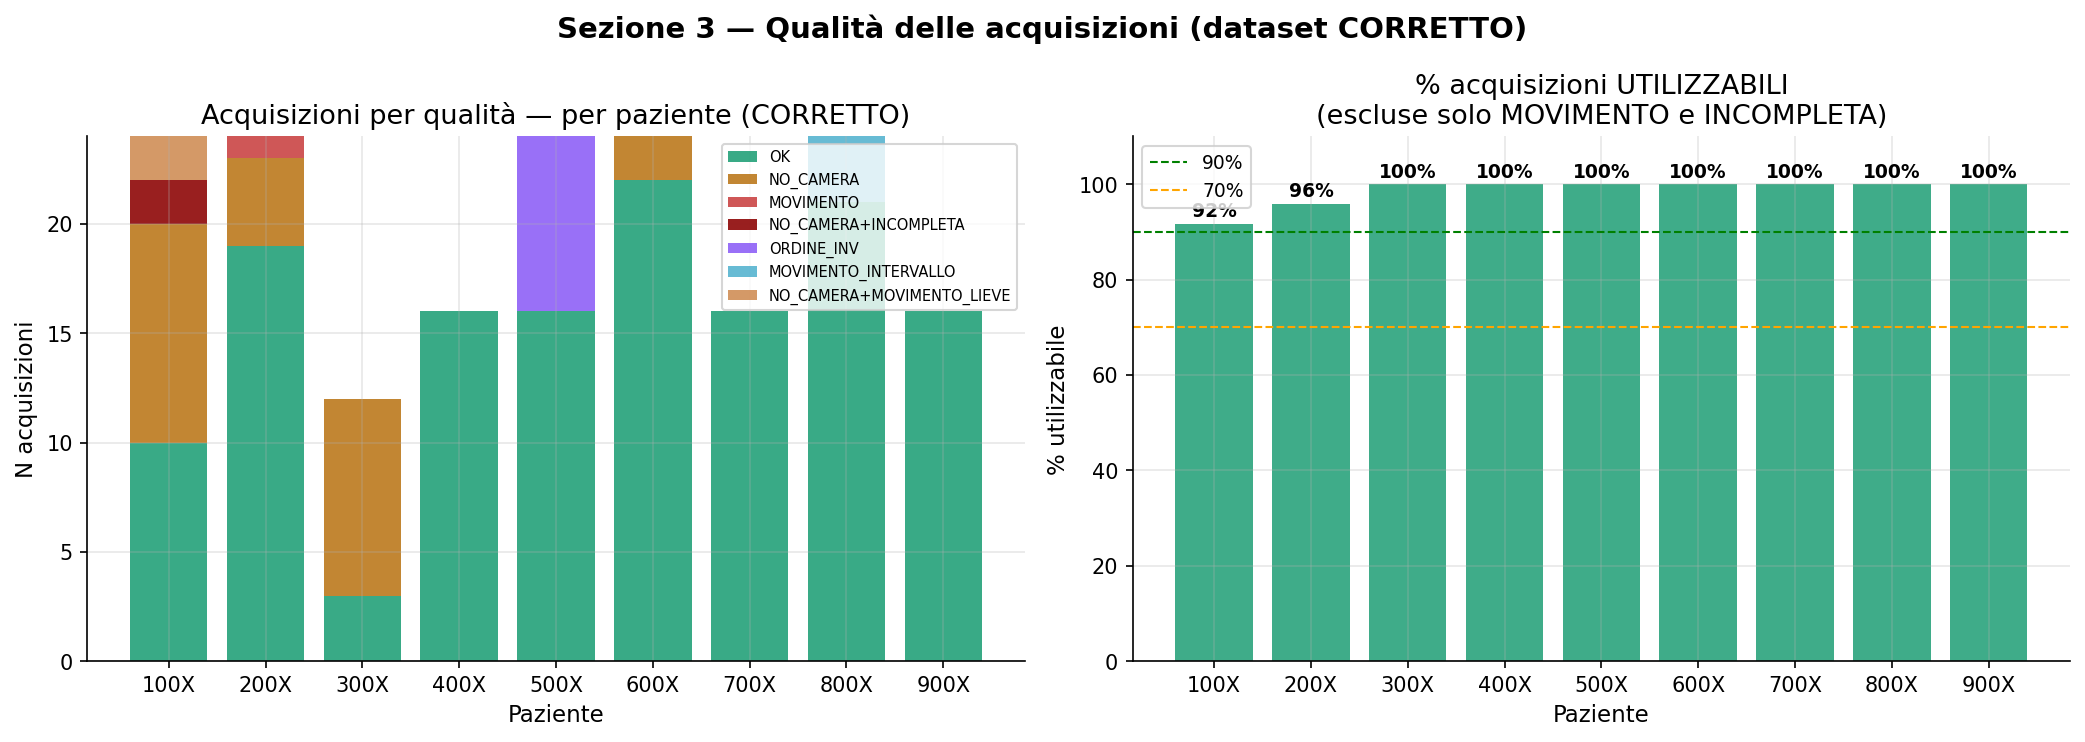

💾 Salvato: flag_qualita_pazienti_corretto.png


In [ ]:
# ── GRAFICO: flag qualità per paziente ──────────────────────────────────────
flag_colors = {
    "OK"                       : "#1D9E75",
    "NO_CAMERA"                : "#BA7517",
    "MOVIMENTO"                : "#c94040",
    "NO_CAMERA+INCOMPLETA"     : "#8b0000",
    "ORDINE_INV"               : "#8b5cf6",
    "MOVIMENTO_LIEVE"          : "#e0a458",
    "MOVIMENTO_INTERVALLO"     : "#52b2cf",
    "NO_CAMERA+MOVIMENTO_LIEVE": "#cf8b52",
}

patients_sorted = sorted(df["Patient"].unique())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

flag_types = list(flag_colors.keys())
bottom = np.zeros(len(patients_sorted))
for flag in flag_types:
    vals = [len(df[(df["Patient"]==p)&(df["flag_qualita"]==flag)]) for p in patients_sorted]
    if sum(vals) == 0: continue
    axes[0].bar(patients_sorted, vals, bottom=bottom, color=flag_colors[flag], label=flag, alpha=0.88)
    bottom += np.array(vals)

axes[0].set_title("Acquisizioni per qualità — per paziente (CORRETTO)")
axes[0].set_xlabel("Paziente"); axes[0].set_ylabel("N acquisizioni")
axes[0].legend(fontsize=7, loc="upper right")

pct_ok_or_lieve = [
    len(df[(df["Patient"]==p) & (~df["flag_qualita"].isin(["MOVIMENTO","NO_CAMERA+INCOMPLETA"]))]) /
    len(df[df["Patient"]==p]) * 100
    for p in patients_sorted
]
bar_cols = ["#1D9E75" if v>=90 else "#BA7517" if v>=70 else "#c94040" for v in pct_ok_or_lieve]
bars = axes[1].bar(patients_sorted, pct_ok_or_lieve, color=bar_cols, alpha=0.85)
axes[1].axhline(90, color="green",  linestyle="--", linewidth=1, label="90%")
axes[1].axhline(70, color="orange", linestyle="--", linewidth=1, label="70%")
axes[1].set_ylim(0, 110); axes[1].set_title("% acquisizioni UTILIZZABILI\n(escluse solo MOVIMENTO e INCOMPLETA)")
axes[1].set_xlabel("Paziente"); axes[1].set_ylabel("% utilizzabile")
axes[1].legend(fontsize=9)
for bar, v in zip(bars, pct_ok_or_lieve):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+1.5, f"{v:.0f}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Sezione 3 — Qualità delle acquisizioni (dataset CORRETTO)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/flag_qualita_pazienti_corretto.png")
plt.show()
print("💾 Salvato: flag_qualita_pazienti_corretto.png")

In [ ]:
# ── TABELLA DETTAGLIATA FLAG ────────────────────────────────────────────────
df_flags = df[df["flag_qualita"] != "OK"][[
    "Patient","Eta","Fase","Breast","Acq_n","Cup","Cup_Role",
    "flag_qualita","max_n","max2avg"
]].copy()

print(f"📋 Acquisizioni con flag ({len(df_flags)} su {len(df)} totali = "
      f"{len(df_flags)/len(df)*100:.1f}%):")
display(df_flags)
df_flags.to_csv(f"{OUTPUT_DIR}/flag_qualita_dettaglio_corretto.csv", index=False)
print("💾 Salvato: flag_qualita_dettaglio_corretto.csv")

📋 Acquisizioni con flag (41 su 180 totali = 22.8%):


,Patient,Eta,Fase,Breast,Acq_n,Cup,Cup_Role,flag_qualita,max_n,max2avg
0,100X,56,1,LEFT,1,II,Base,NO_CAMERA+MOVIMENTO_LIEVE,0.577395,1.961391
1,100X,56,1,LEFT,2,II,Base,NO_CAMERA+MOVIMENTO_LIEVE,0.779476,2.586944
2,100X,56,1,RIGHT,1,II,Base,NO_CAMERA,0.897077,2.741180
3,100X,56,1,RIGHT,2,II,Base,NO_CAMERA,0.885216,2.996218
4,100X,56,2,LEFT,1,II,Base,NO_CAMERA,0.699525,2.223376
5,100X,56,2,LEFT,2,II,Base,NO_CAMERA,0.457369,1.992624
6,100X,56,2,RIGHT,1,II,Base,NO_CAMERA,0.760829,2.405637
7,100X,56,2,RIGHT,2,II,Base,NO_CAMERA,0.696359,2.526393
8,100X,56,3,LEFT,1,III,Base+1,NO_CAMERA,0.577457,2.246916
9,100X,56,3,LEFT,2,III,Base+1,NO_CAMERA,0.892921,3.238787


💾 Salvato: flag_qualita_dettaglio_corretto.csv


## 4. Analisi comparativa — Dataset completo vs Dataset pulito

**Regola di esclusione aggiornata:** solo `MOVIMENTO` (confermato durante l'acquisizione)
e `NO_CAMERA+INCOMPLETA` vengono esclusi. `MOVIMENTO_LIEVE` e `MOVIMENTO_INTERVALLO`
**vengono mantenuti** perché non corrompono la misura.

In [ ]:
# ── COSTRUZIONE DATASET PULITO ──────────────────────────────────────────────
EXCLUDE_FLAGS = {"MOVIMENTO", "NO_CAMERA+INCOMPLETA"}

df_clean = df[~df["flag_qualita"].isin(EXCLUDE_FLAGS)].copy()

# Correggi ordine sessione per 500X (fasi 5 e 6 invertite)
mask_inv = (df_clean["Patient"] == "500X") & (df_clean["Fase"].isin([5, 6]))
df_clean.loc[mask_inv & (df_clean["Fase"]==5), "Sessione"] = "B"
df_clean.loc[mask_inv & (df_clean["Fase"]==6), "Sessione"] = "A"

print("📊 Confronto dataset completo vs pulito (CORRETTO):")
print(f"   Completo : {len(df):>4} acquisizioni")
print(f"   Pulito   : {len(df_clean):>4} acquisizioni  "
      f"(escluse {len(df)-len(df_clean)} per MOVIMENTO/INCOMPLETA)")
print()
print("   Acquisizioni escluse per tipo:")
for flag in EXCLUDE_FLAGS:
    n = len(df[df["flag_qualita"]==flag])
    print(f"     {flag:<30} : {n}")
print()
print("   Acquisizioni mantenute con flag informativo (non escluse):")
for flag in ["NO_CAMERA","NO_CAMERA+MOVIMENTO_LIEVE","MOVIMENTO_INTERVALLO","ORDINE_INV"]:
    n = len(df_clean[df_clean["flag_qualita"]==flag])
    if n>0: print(f"     {flag:<30} : {n}")

📊 Confronto dataset completo vs pulito (CORRETTO):
   Completo :  180 acquisizioni
   Pulito   :  177 acquisizioni  (escluse 3 per MOVIMENTO/INCOMPLETA)

   Acquisizioni escluse per tipo:
     NO_CAMERA+INCOMPLETA           : 2
     MOVIMENTO                      : 1

   Acquisizioni mantenute con flag informativo (non escluse):
     NO_CAMERA                      : 25
     NO_CAMERA+MOVIMENTO_LIEVE      : 2
     MOVIMENTO_INTERVALLO           : 3
     ORDINE_INV                     : 8


In [ ]:
# ── COPPIE INTRA-SESSIONE: completo vs pulito ────────────────────────────────
def build_pairs(data):
    d = data.copy()
    pc = d.groupby(["Patient","Fase","Breast"]).size().reset_index(name="pc")
    d  = d.merge(pc, on=["Patient","Fase","Breast"])
    d  = d[d["pc"] == 2].copy()
    d["acq_n_local"] = d.groupby(["Patient","Fase","Breast"]).cumcount() + 1

    a1 = d[d["acq_n_local"]==1].set_index(["Patient","Fase","Breast"])
    a2 = d[d["acq_n_local"]==2].set_index(["Patient","Fase","Breast"])

    p = a1[METRICS].join(a2[METRICS], lsuffix="_1", rsuffix="_2")
    p = p.join(a1[["Cup","Cup_Role","Sessione","Mis_norm","Eta","flag_qualita"]])
    p = p.reset_index()

    for m in METRICS:
        mean_ = (p[f"{m}_1"] + p[f"{m}_2"]) / 2
        diff_ = (p[f"{m}_1"] - p[f"{m}_2"]).abs()
        p[f"{m}_mean"] = mean_
        p[f"{m}_cv"]   = diff_ / mean_ * 100
    return p

pairs_full  = build_pairs(df)
pairs_clean = build_pairs(df_clean)

print(f"✅ Coppie intra-sessione:")
print(f"   Dataset completo : {len(pairs_full)} coppie")
print(f"   Dataset pulito   : {len(pairs_clean)} coppie")
print()
print("   Coppie 800X ripristinate (ora valide nel dataset pulito):")
sub800 = pairs_clean[pairs_clean["Patient"]=="800X"]
display(sub800[["Fase","Breast","Cup","Cup_Role","max_n_1","max_n_2","max_n_cv"]])

pairs = pairs_clean.copy()
print()
print("ℹ️  Da qui in poi 'pairs' = dataset PULITO CORRETTO.")

✅ Coppie intra-sessione:
   Dataset completo : 86 coppie
   Dataset pulito   : 85 coppie

   Coppie 800X ripristinate (ora valide nel dataset pulito):


,Fase,Breast,Cup,Cup_Role,max_n_1,max_n_2,max_n_cv
65,1,LEFT,I,Base-1,0.166608,0.173541,4.076230
66,1,RIGHT,I,Base-1,0.146643,0.171648,15.712019
67,2,LEFT,I,Base-1,0.137493,0.156297,12.800912
68,2,RIGHT,I,Base-1,0.200572,0.185689,7.706178
69,3,LEFT,II,Base,0.153576,0.159703,3.911541
70,3,RIGHT,II,Base,0.155677,0.179393,14.156072
71,4,LEFT,II,Base,0.142510,0.143366,0.598569
72,4,RIGHT,II,Base,0.148498,0.155913,4.871726
73,5,LEFT,III teflon,Base+1,0.152698,0.199516,26.585428
74,5,RIGHT,III teflon,Base+1,0.199178,0.209629,5.112883



ℹ️  Da qui in poi 'pairs' = dataset PULITO CORRETTO.


In [ ]:
# ── CONFRONTO CV%: completo vs pulito ────────────────────────────────────────
def color_cv(val):
    try:
        v = float(str(val).replace('%',''))
        if v < 10:  return 'background-color: #c6efce'
        if v < 15:  return 'background-color: #ffeb9c'
        if v < 25:  return 'background-color: #fce4d6'
        return 'background-color: #ffc7ce'
    except: return ''

def color_impact(val):
    c = {"Trascurabile": "background-color:#c6efce",
         "Lieve"       : "background-color:#ffeb9c",
         "Moderato"    : "background-color:#fce4d6",
         "Significativo":"background-color:#ffc7ce"}
    return c.get(str(val), "")

print("📊 Impatto dei flag sulla ripetibilità — CV% medio (dataset CORRETTO):")
compare_rows = []
for m in METRICS:
    cv_full  = pairs_full[f"{m}_cv"].mean()
    cv_clean = pairs_clean[f"{m}_cv"].mean()
    delta    = cv_clean - cv_full
    compare_rows.append({
        "Metrica"      : m,
        "CV% completo" : round(cv_full,  2),
        "CV% pulito"   : round(cv_clean, 2),
        "Δ CV%"        : round(delta, 2),
        "Impatto"      : "Trascurabile" if abs(delta)<1 else
                         "Lieve"        if abs(delta)<3 else
                         "Moderato"     if abs(delta)<5 else "Significativo",
    })

df_compare = pd.DataFrame(compare_rows)
display(df_compare.style
    .applymap(color_cv,     subset=["CV% completo","CV% pulito"])
    .applymap(color_impact, subset=["Impatto"])
    .set_caption("Confronto CV% — dataset completo vs pulito (CORRETTO)"))
df_compare.to_csv(f"{OUTPUT_DIR}/confronto_completo_vs_pulito_corretto.csv", index=False)
print("💾 Salvato: confronto_completo_vs_pulito_corretto.csv")

📊 Impatto dei flag sulla ripetibilità — CV% medio (dataset CORRETTO):


,Metrica,CV% completo,CV% pulito,Δ CV%,Impatto
0,max_n,11.430000,11.440000,0.000000,Trascurabile
1,max2avg,7.870000,7.880000,0.020000,Trascurabile
2,var_p,53.280000,53.230000,-0.050000,Trascurabile
3,mad_p,30.830000,30.810000,-0.020000,Trascurabile
4,var_r,56.030000,55.890000,-0.140000,Trascurabile


💾 Salvato: confronto_completo_vs_pulito_corretto.csv


📋 Profilo per paziente con ETÀ CORRETTE:


,Paziente,Età,max_n_medio,max2avg_medio,max_n_CV%,max2avg_CV%,Taglia
0,100X,56,0.7679,2.4554,18.33,15.35,Tg.IV
1,200X,46,0.3653,2.2995,10.71,7.90,Tg.II
2,300X,68,0.7508,2.3640,14.28,4.92,Tg.IV
3,400X,64,0.4721,2.2725,14.07,8.82,Tg.III
4,500X,54,0.2997,2.0249,6.72,4.57,Tg.II
5,600X,43,0.2483,2.0580,6.32,4.20,Tg.II
6,700X,64,0.3127,2.1017,16.33,9.48,Tg.IIIc
7,800X,47,0.1667,1.7381,8.08,7.86,Tg.II
8,900X,53,0.3217,2.1664,14.68,8.02,Tg.II



📊 Correlazione Spearman età → metriche (con età corrette):
   Età vs max_n_medio         : r=+0.594  p=0.0916  ns
   Età vs max2avg_medio       : r=+0.435  p=0.2418  ns
   Età vs max_n_CV%           : r=+0.611  p=0.0805  ns
   Età vs max2avg_CV%         : r=+0.427  p=0.2520  ns


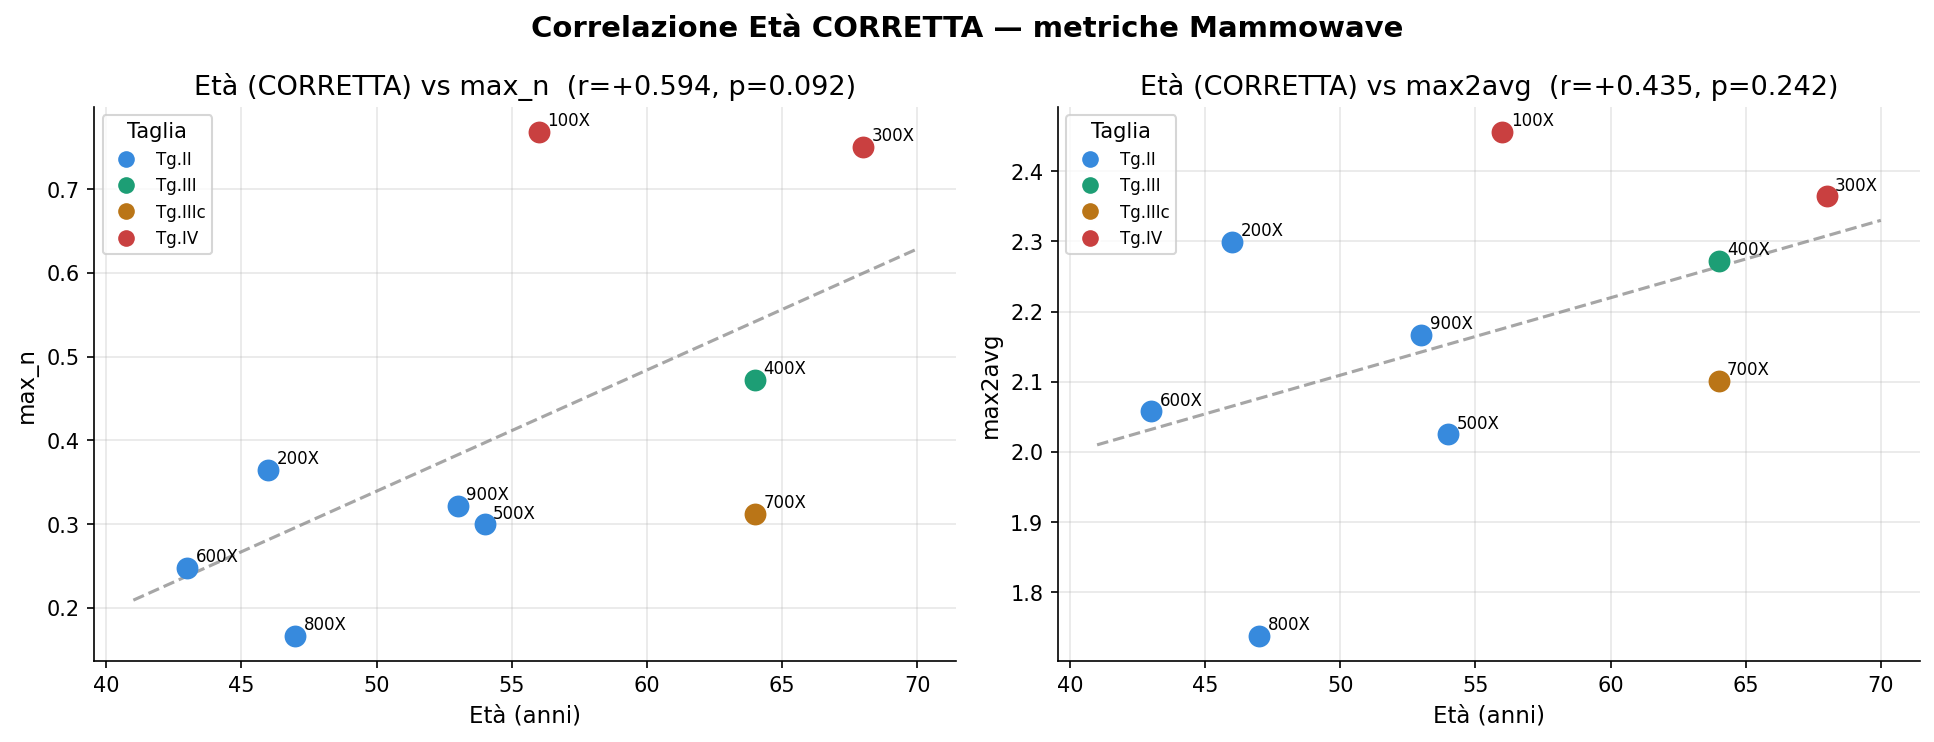

💾 Salvato: eta_vs_metriche_corretto.png


In [ ]:
# ── CORRELAZIONE ETÀ (con età corrette) ─────────────────────────────────────
age_rows = []
for p in sorted(pairs_clean["Patient"].unique()):
    sub = pairs_clean[pairs_clean["Patient"]==p]
    eta = sub["Eta"].iloc[0]
    age_rows.append({
        "Paziente"     : p,
        "Età"          : eta,
        "max_n_medio"  : round(sub["max_n_mean"].mean(), 4),
        "max2avg_medio": round(sub["max2avg_mean"].mean(), 4),
        "max_n_CV%"    : round(sub["max_n_cv"].mean(), 2),
        "max2avg_CV%"  : round(sub["max2avg_cv"].mean(), 2),
        "Taglia"       : sub["Mis_norm"].iloc[0],
    })
df_age = pd.DataFrame(age_rows)
print("📋 Profilo per paziente con ETÀ CORRETTE:")
display(df_age)

print()
print("📊 Correlazione Spearman età → metriche (con età corrette):")
for col in ["max_n_medio","max2avg_medio","max_n_CV%","max2avg_CV%"]:
    r, p = spearmanr(df_age["Età"], df_age[col])
    sig  = "* p<0.05" if p<0.05 else "ns"
    print(f"   Età vs {col:<20}: r={r:+.3f}  p={p:.4f}  {sig}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax_i, (metric, label) in enumerate([("max_n_medio","max_n"), ("max2avg_medio","max2avg")]):
    for _, row in df_age.iterrows():
        axes[ax_i].scatter(row["Età"], row[metric], s=90, zorder=3,
                           color={"Tg.II":"#378ADD","Tg.III":"#1D9E75",
                                  "Tg.IIIc":"#BA7517","Tg.IV":"#c94040"}
                                 .get(row["Taglia"],"#888"))
        axes[ax_i].annotate(row["Paziente"], (row["Età"], row[metric]), fontsize=8,
            xytext=(4, 3), textcoords="offset points")
    r, p = spearmanr(df_age["Età"], df_age[metric])
    m_lr, b_lr = np.polyfit(df_age["Età"], df_age[metric], 1)
    x_lr = np.linspace(df_age["Età"].min()-2, df_age["Età"].max()+2, 100)
    axes[ax_i].plot(x_lr, m_lr*x_lr+b_lr, "--", color="gray", linewidth=1.5, alpha=0.7)
    axes[ax_i].set_xlabel("Età (anni)"); axes[ax_i].set_ylabel(label)
    axes[ax_i].set_title(f"Età (CORRETTA) vs {label}  (r={r:+.3f}, p={p:.3f})")
    leg = [Line2D([0],[0],marker="o",color="w",markerfacecolor=c,markersize=9,label=t)
           for t,c in [("Tg.II","#378ADD"),("Tg.III","#1D9E75"),("Tg.IIIc","#BA7517"),("Tg.IV","#c94040")]]
    axes[ax_i].legend(handles=leg, fontsize=8, title="Taglia")

plt.suptitle("Correlazione Età CORRETTA — metriche Mammowave", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eta_vs_metriche_corretto.png")
plt.show()
print("💾 Salvato: eta_vs_metriche_corretto.png")
df_age.to_csv(f"{OUTPUT_DIR}/profilo_paziente_eta_corretto.csv", index=False)

## 5. Ripetibilità intra-sessione


In [ ]:
# ── FUNZIONI: CV%, SEM, MDC ──────────────────────────────────────────────────
def cv_pct(arr1, arr2):
    arr1, arr2 = np.array(arr1, dtype=float), np.array(arr2, dtype=float)
    diffs = np.abs(arr1 - arr2)
    means = (arr1 + arr2) / 2
    return float(np.mean(diffs / means * 100))

def compute_sem(diff_array):
    return float(np.std(diff_array, ddof=1) / np.sqrt(2))

def compute_mdc(diff_array, z=1.96):
    return float(z * compute_sem(diff_array) * np.sqrt(2))

def compute_mdc_pct(diff_array, mean_val):
    return float(compute_mdc(diff_array) / mean_val * 100) if mean_val != 0 else np.nan

def color_mdcp(val):
    try:
        v = float(str(val).replace('%',''))
        if v < 15:  return 'background-color: #c6efce'
        if v < 25:  return 'background-color: #ffeb9c'
        if v < 40:  return 'background-color: #fce4d6'
        return 'background-color: #ffc7ce'
    except: return ''

print("✅ Funzioni CV%, SEM, MDC definite")

✅ Funzioni CV%, SEM, MDC definite


In [ ]:
# ── TABELLA: CV%, SEM, MDC per metrica e seno ───────────────────────────────
rows = []
for m in METRICS:
    a1_all = pairs[f"{m}_1"].values
    a2_all = pairs[f"{m}_2"].values
    diff_all = a1_all - a2_all
    mean_all = np.mean((a1_all + a2_all) / 2)
    rows.append({
        "Metrica":m, "Seno":"GLOBALE", "N":len(a1_all),
        "CV% medio": round(cv_pct(a1_all,a2_all),2),
        "SEM": round(compute_sem(diff_all),4),
        "MDC95": round(compute_mdc(diff_all),4),
        "MDC%": round(compute_mdc_pct(diff_all,mean_all),2),
    })
    for breast in ["LEFT","RIGHT"]:
        mask = pairs["Breast"]==breast
        a1b, a2b = pairs.loc[mask,f"{m}_1"].values, pairs.loc[mask,f"{m}_2"].values
        diffb, meanb = a1b-a2b, np.mean((a1b+a2b)/2)
        rows.append({
            "Metrica":m, "Seno":breast, "N":int(mask.sum()),
            "CV% medio": round(cv_pct(a1b,a2b),2),
            "SEM": round(compute_sem(diffb),4),
            "MDC95": round(compute_mdc(diffb),4),
            "MDC%": round(compute_mdc_pct(diffb,meanb),2),
        })

df_sem_mdc = pd.DataFrame(rows)
print("📋 Tabella CV%, SEM, MDC — intra-sessione (dataset CORRETTO):")
display(df_sem_mdc.style
    .applymap(color_cv,   subset=["CV% medio"])
    .applymap(color_mdcp, subset=["MDC%"])
    .set_caption("Ripetibilità intra-sessione (dataset corretto)"))
df_sem_mdc.to_csv(f"{OUTPUT_DIR}/passo2_cv_sem_mdc_corretto.csv", index=False)

📋 Tabella CV%, SEM, MDC — intra-sessione (dataset CORRETTO):


,Metrica,Seno,N,CV% medio,SEM,MDC95,MDC%
0,max_n,GLOBALE,85,11.440000,0.059600,0.165200,43.700000
1,max_n,LEFT,42,13.580000,0.074600,0.206900,56.470000
2,max_n,RIGHT,43,9.340000,0.040800,0.113000,29.020000
3,max2avg,GLOBALE,85,7.880000,0.178800,0.495600,23.210000
4,max2avg,LEFT,42,9.370000,0.207600,0.575500,27.090000
5,max2avg,RIGHT,43,6.440000,0.147200,0.408100,19.020000
6,var_p,GLOBALE,85,53.230000,0.031300,0.086700,210.250000
7,var_p,LEFT,42,58.150000,0.035700,0.098800,240.930000
8,var_p,RIGHT,43,48.430000,0.026700,0.073900,178.110000
9,mad_p,GLOBALE,85,30.810000,0.040600,0.112400,88.300000


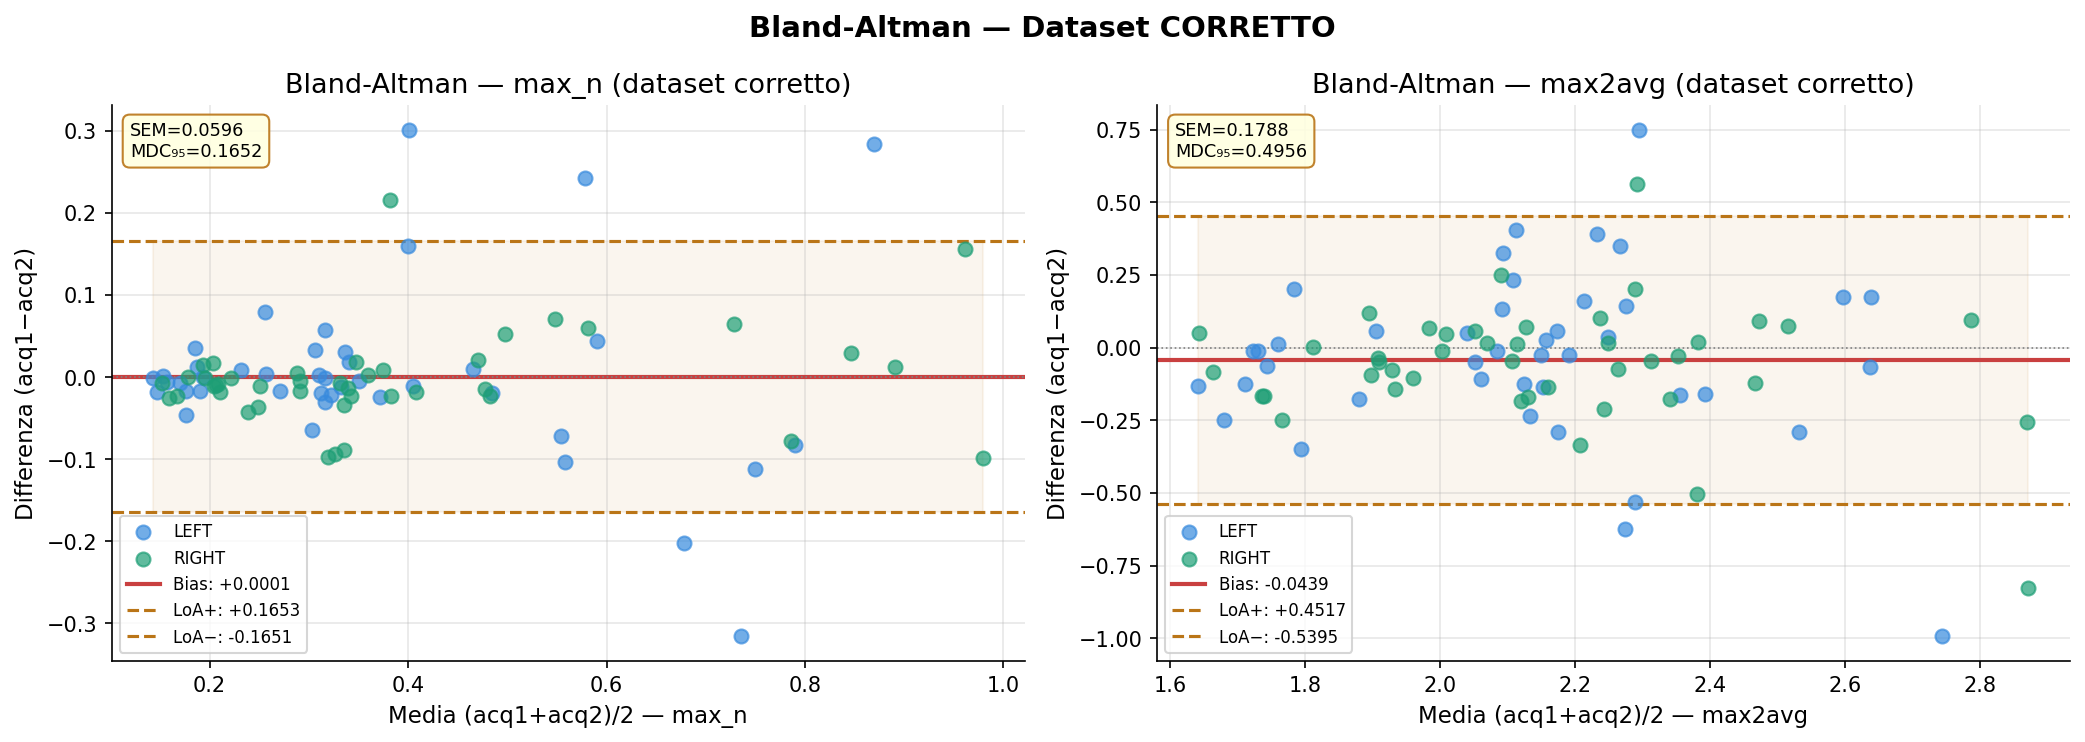

💾 Salvato: passo2_bland_altman_corretto.png


In [ ]:
# ── BLAND-ALTMAN intra-sessione ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_i, metric in enumerate(["max_n", "max2avg"]):
    a1 = pairs[f"{metric}_1"].values; a2 = pairs[f"{metric}_2"].values
    mean_ba = (a1+a2)/2; diff_ba = a1-a2
    bias = np.mean(diff_ba); sd = np.std(diff_ba, ddof=1)
    loa_up, loa_dn = bias+1.96*sd, bias-1.96*sd
    sem_val, mdc_val = compute_sem(diff_ba), compute_mdc(diff_ba)

    col_map = {"LEFT":"#378ADD","RIGHT":"#1D9E75"}
    for breast in ["LEFT","RIGHT"]:
        mask = pairs["Breast"]==breast
        axes[ax_i].scatter(mean_ba[mask], diff_ba[mask], c=col_map[breast], alpha=0.7, s=45, zorder=3, label=breast)

    axes[ax_i].axhline(bias, color="#c94040", linewidth=2, label=f"Bias: {bias:+.4f}")
    axes[ax_i].axhline(loa_up, color="#BA7517", linewidth=1.5, linestyle="--", label=f"LoA+: {loa_up:+.4f}")
    axes[ax_i].axhline(loa_dn, color="#BA7517", linewidth=1.5, linestyle="--", label=f"LoA−: {loa_dn:+.4f}")
    axes[ax_i].axhline(0, color="gray", linewidth=0.8, linestyle=":")
    axes[ax_i].fill_between([mean_ba.min(),mean_ba.max()], loa_dn, loa_up, alpha=0.07, color="#BA7517")
    axes[ax_i].set_xlabel(f"Media (acq1+acq2)/2 — {metric}")
    axes[ax_i].set_ylabel("Differenza (acq1−acq2)")
    axes[ax_i].set_title(f"Bland-Altman — {metric} (dataset corretto)")
    axes[ax_i].legend(fontsize=8)
    axes[ax_i].text(0.02, 0.97, f"SEM={sem_val:.4f}\nMDC₉₅={mdc_val:.4f}",
        transform=axes[ax_i].transAxes, fontsize=8.5, va="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", edgecolor="#BA7517", alpha=0.9))

plt.suptitle("Bland-Altman — Dataset CORRETTO", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/passo2_bland_altman_corretto.png")
plt.show()
print("💾 Salvato: passo2_bland_altman_corretto.png")

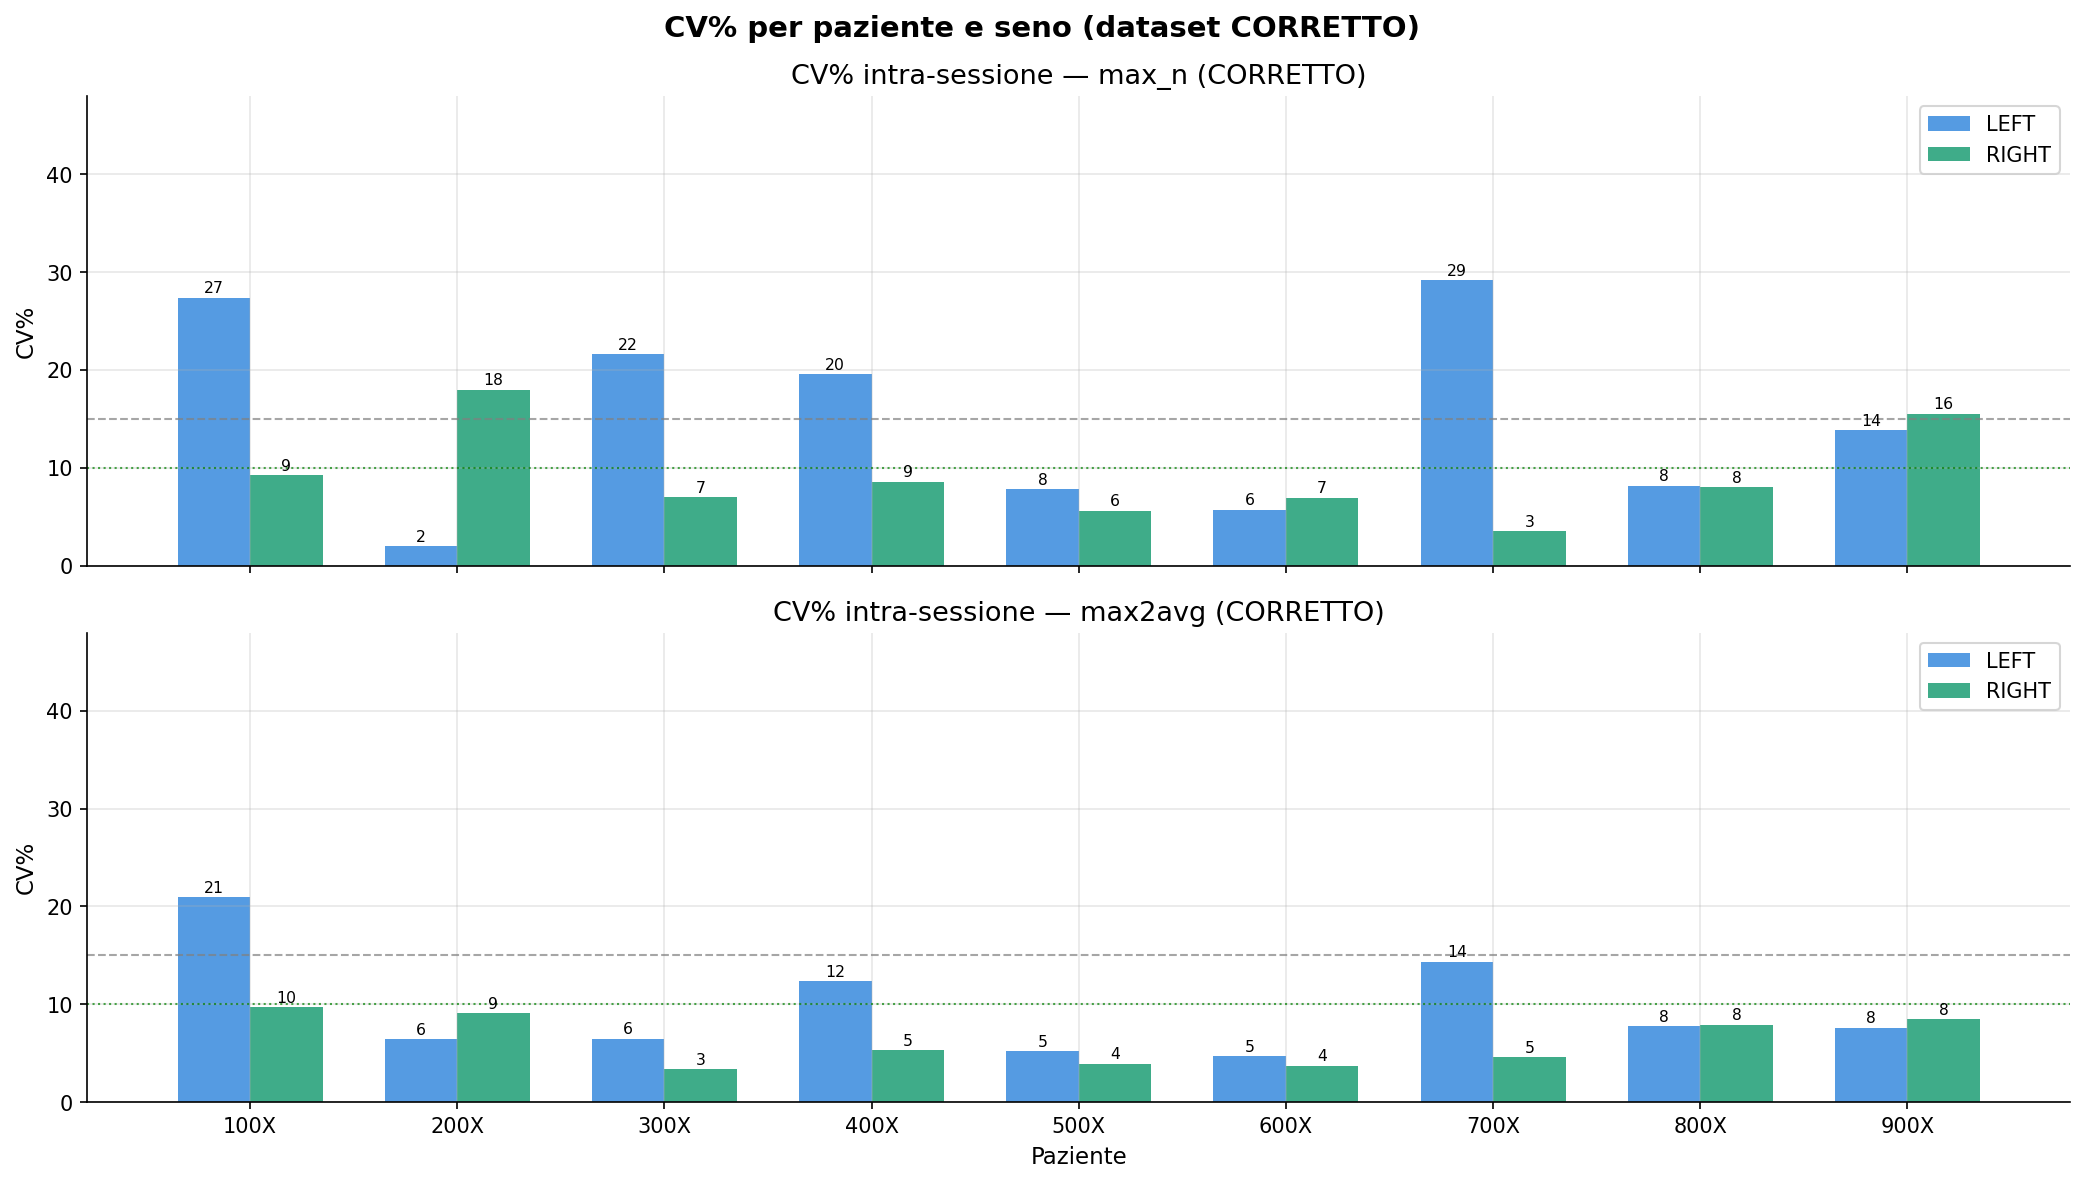

💾 Salvato: passo2_cv_per_paziente_corretto.png


In [ ]:
# ── CV% per paziente e seno ──────────────────────────────────────────────────
patients = sorted(pairs["Patient"].unique())
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
x = np.arange(len(patients)); w = 0.35

for ax_i, (metric, title) in enumerate([("max_n","max_n"), ("max2avg","max2avg")]):
    cv_l = [pairs[(pairs["Patient"]==p)&(pairs["Breast"]=="LEFT")][f"{metric}_cv"].mean() for p in patients]
    cv_r = [pairs[(pairs["Patient"]==p)&(pairs["Breast"]=="RIGHT")][f"{metric}_cv"].mean() for p in patients]
    axes[ax_i].bar(x-w/2, cv_l, w, label="LEFT",  color="#378ADD", alpha=0.85)
    axes[ax_i].bar(x+w/2, cv_r, w, label="RIGHT", color="#1D9E75", alpha=0.85)
    axes[ax_i].axhline(15, color="gray",  linestyle="--", linewidth=1, alpha=0.7)
    axes[ax_i].axhline(10, color="green", linestyle=":",  linewidth=1, alpha=0.7)
    axes[ax_i].set_title(f"CV% intra-sessione — {title} (CORRETTO)")
    axes[ax_i].set_ylabel("CV%"); axes[ax_i].legend(); axes[ax_i].set_ylim(0, 48)
    for i_, (vl, vr) in enumerate(zip(cv_l, cv_r)):
        axes[ax_i].text(i_-w/2, vl+0.5, f"{vl:.0f}", ha="center", fontsize=7.5)
        axes[ax_i].text(i_+w/2, vr+0.5, f"{vr:.0f}", ha="center", fontsize=7.5)

axes[1].set_xticks(x); axes[1].set_xticklabels(patients)
axes[1].set_xlabel("Paziente")
plt.suptitle("CV% per paziente e seno (dataset CORRETTO)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/passo2_cv_per_paziente_corretto.png")
plt.show()
print("💾 Salvato: passo2_cv_per_paziente_corretto.png")

## 6. Test di normalità (Shapiro-Wilk)
Verifica formale che giustifica l'uso di test non-parametrici (Kruskal-Wallis,
Mann-Whitney, Spearman) invece di ANOVA/t-test/Pearson.

In [ ]:
# ── SHAPIRO-WILK per metrica ────────────────────────────────────
print("📊 Test di Shapiro-Wilk — normalità per metrica (globale):")
sw_rows = []
for m in METRICS:
    vals = pairs[f"{m}_mean"].values
    stat, p = shapiro(vals)
    sw_rows.append({"Metrica":m, "N":len(vals), "W":round(stat,3), "p":round(p,4),
                    "Normale?": "Sì" if p>0.05 else "NO"})
df_sw = pd.DataFrame(sw_rows)

def color_normal(val):
    return 'background-color:#ffc7ce' if val=='NO' else 'background-color:#c6efce'

display(df_sw.style.applymap(color_normal, subset=["Normale?"])
    .set_caption("Shapiro-Wilk — se 'NO' usare test non-parametrici (KW, MW, Spearman)"))
print()
print("ℹ️  Interpretazione: la maggior parte delle metriche NON è distribuita normalmente.")
print("   Questo conferma che l'uso di Kruskal-Wallis, Mann-Whitney e Spearman")
print("   (invece di ANOVA, t-test, Pearson) è la scelta metodologicamente corretta.")
df_sw.to_csv(f"{OUTPUT_DIR}/shapiro_wilk_normalita.csv", index=False)

📊 Test di Shapiro-Wilk — normalità per metrica (globale):


,Metrica,N,W,p,Normale?
0,max_n,85,0.862000,0.000000,NO
1,max2avg,85,0.969000,0.041000,NO
2,var_p,85,0.791000,0.000000,NO
3,mad_p,85,0.959000,0.008800,NO
4,var_r,85,0.815000,0.000000,NO



ℹ️  Interpretazione: la maggior parte delle metriche NON è distribuita normalmente.
   Questo conferma che l'uso di Kruskal-Wallis, Mann-Whitney e Spearman
   (invece di ANOVA, t-test, Pearson) è la scelta metodologicamente corretta.


## 7. Ripetibilità inter-sessione
Confronto Sessione A (fasi dispari) vs Sessione B (fasi pari) — stessa coppa,
riposizionamento dopo 30 min. Dataset CORRETTO (include le coppie 800X ripristinate).

In [ ]:
# ── COSTRUZIONE DATASET INTER-SESSIONE ────────────────────────────────────
for m in METRICS:
    pairs[f"{m}_mean"] = (pairs[f"{m}_1"] + pairs[f"{m}_2"]) / 2

mean_cols = [f"{m}_mean" for m in METRICS]
sessA = pairs[pairs["Sessione"]=="A"].set_index(["Patient","Breast","Cup_Role"])
sessB = pairs[pairs["Sessione"]=="B"].set_index(["Patient","Breast","Cup_Role"])

inter = (sessA[mean_cols + ["Cup","Mis_norm"]]
         .join(sessB[mean_cols], lsuffix="_A", rsuffix="_B")
         .reset_index())
inter_clean = inter.dropna(subset=[f"{m}_mean_A" for m in METRICS] +
                                   [f"{m}_mean_B" for m in METRICS]).copy()

for m in METRICS:
    A = inter_clean[f"{m}_mean_A"]; B = inter_clean[f"{m}_mean_B"]
    inter_clean[f"{m}_icv"] = ((A-B).abs() / ((A+B)/2) * 100)

print(f"✅ Dataset inter-sessione (CORRETTO): {len(inter_clean)} coppie A↔B complete")

✅ Dataset inter-sessione (CORRETTO): 41 coppie A↔B complete


In [ ]:
# ── TABELLA CONFRONTO INTRA vs INTER ────────────────────────────────────────
rows_inter = []
for m in METRICS:
    A = inter_clean[f"{m}_mean_A"].values; B = inter_clean[f"{m}_mean_B"].values
    icv = inter_clean[f"{m}_icv"].values
    cv_i = pairs[f"{m}_cv"].mean(); cv_e = np.mean(icv)
    diff_intra = pairs[f"{m}_1"].values - pairs[f"{m}_2"].values
    mean_v = np.mean((pairs[f"{m}_1"].values+pairs[f"{m}_2"].values)/2)
    rows_inter.append({
        "Metrica":m,
        "CV% intra": round(cv_i,2), "CV% inter": round(cv_e,2),
        "Ratio inter/intra": round(cv_e/cv_i,2),
        "MDC% intra": round(compute_mdc_pct(diff_intra,mean_v),2),
        "MDC% inter": round(compute_mdc_pct(A-B,mean_v),2),
    })

df_inter = pd.DataFrame(rows_inter)
print("📋 Confronto intra vs inter-sessione (dataset CORRETTO):")
display(df_inter.style
    .applymap(color_cv,   subset=["CV% intra","CV% inter"])
    .applymap(color_mdcp, subset=["MDC% intra","MDC% inter"])
    .background_gradient(subset=["Ratio inter/intra"], cmap="RdYlGn_r", vmin=1.0, vmax=3.0)
    .set_caption("Intra vs inter-sessione (dataset corretto)"))
df_inter.to_csv(f"{OUTPUT_DIR}/passo3_inter_vs_intra_corretto.csv", index=False)

📋 Confronto intra vs inter-sessione (dataset CORRETTO):


,Metrica,CV% intra,CV% inter,Ratio inter/intra,MDC% intra,MDC% inter
0,max_n,11.440000,21.290000,1.860000,43.700000,50.710000
1,max2avg,7.880000,9.480000,1.200000,23.210000,23.520000
2,var_p,53.230000,56.780000,1.070000,210.250000,173.260000
3,mad_p,30.810000,33.390000,1.080000,88.300000,86.410000
4,var_r,55.890000,57.930000,1.040000,209.320000,174.080000


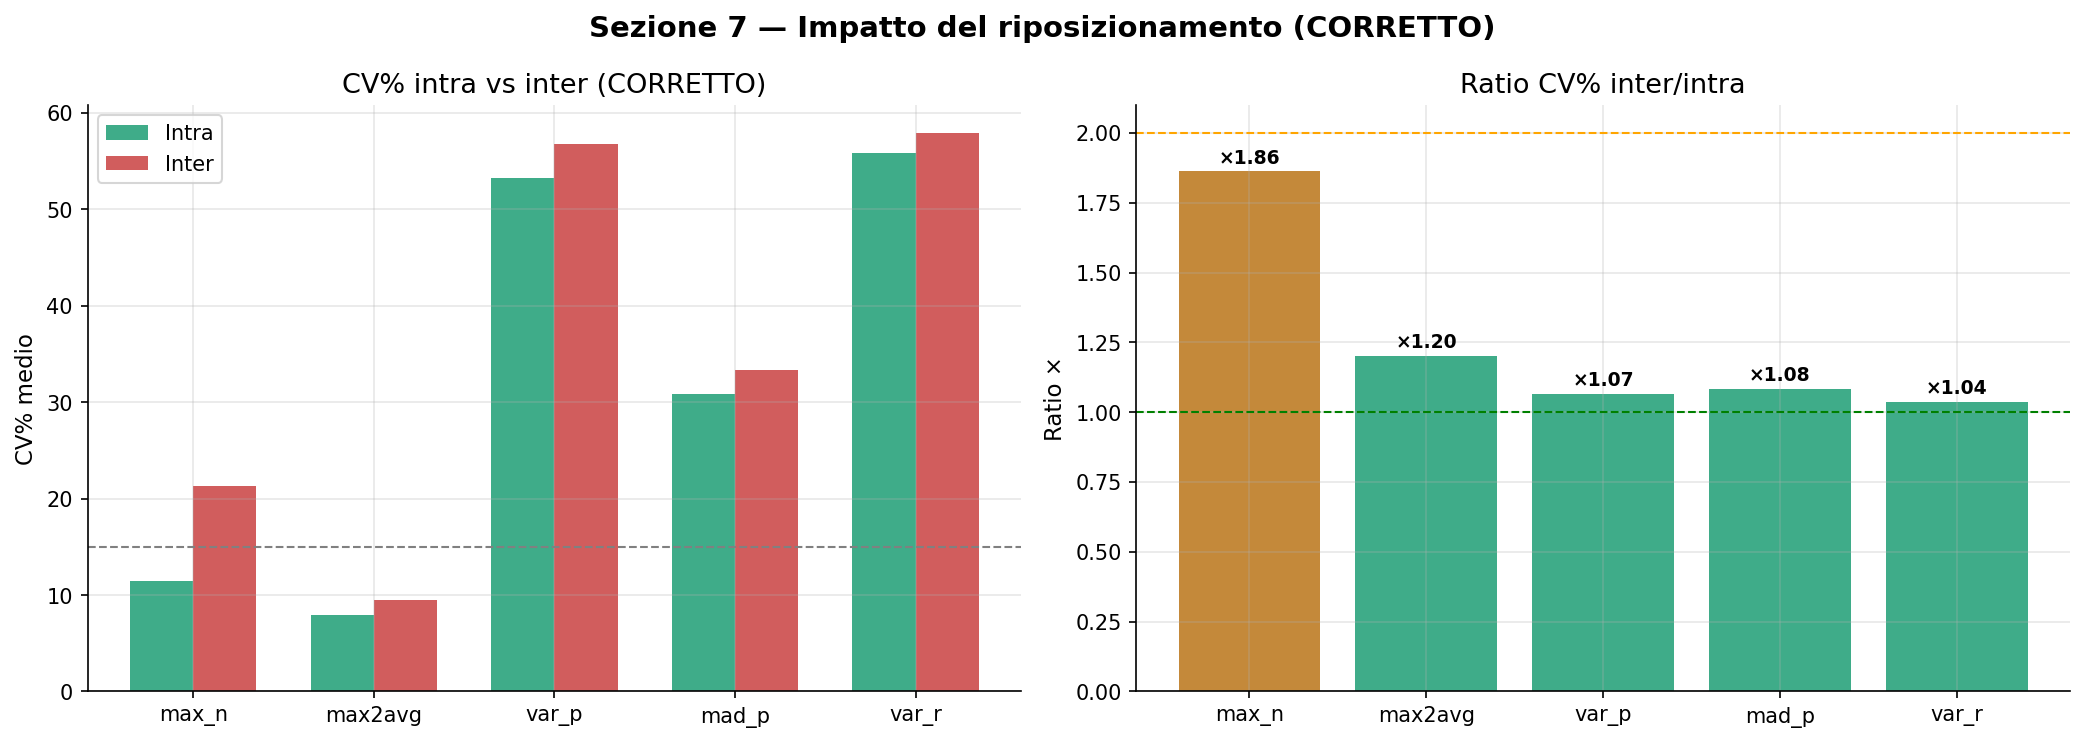

In [ ]:
# ── GRAFICO inter-sessione ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(METRICS)); w = 0.35
cv_intra_vals = [pairs[f"{m}_cv"].mean() for m in METRICS]
cv_inter_vals = [inter_clean[f"{m}_icv"].mean() for m in METRICS]

b1 = axes[0].bar(x-w/2, cv_intra_vals, w, label="Intra", color="#1D9E75", alpha=0.85)
b2 = axes[0].bar(x+w/2, cv_inter_vals, w, label="Inter", color="#c94040", alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(METRICS)
axes[0].set_title("CV% intra vs inter (CORRETTO)"); axes[0].set_ylabel("CV% medio")
axes[0].legend(); axes[0].axhline(15, color="gray", linestyle="--", linewidth=1)

ratios = [cv_inter_vals[i]/cv_intra_vals[i] for i in range(len(METRICS))]
bar_cols = ["#1D9E75" if r<1.5 else "#BA7517" if r<2.0 else "#c94040" for r in ratios]
bars_r = axes[1].bar(METRICS, ratios, color=bar_cols, alpha=0.85)
axes[1].axhline(1.0, color="green",  linestyle="--", linewidth=1)
axes[1].axhline(2.0, color="orange", linestyle="--", linewidth=1)
axes[1].set_title("Ratio CV% inter/intra"); axes[1].set_ylabel("Ratio ×")
for bar, v in zip(bars_r, ratios):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.03, f"×{v:.2f}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Sezione 7 — Impatto del riposizionamento (CORRETTO)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/passo3_inter_sessione_corretto.png")
plt.show()

## 8. Analisi delle coppe — incl. Base (corretta) vs Teflon

**Nuova analisi richiesta:** confronto diretto tra la coppa Base (corretta, tenendo conto
dell'override per 800X) e la coppa III teflon, indipendentemente dal Cup_Role assegnato.

In [ ]:
cups_order = ["I","II","III","III teflon"]
colors_cup = {"I":"#378ADD","II":"#1D9E75","III":"#c94040","III teflon":"#BA7517"}

cup_stats = []
for cup in cups_order:
    sub = pairs[pairs["Cup"]==cup]
    for m in ["max_n","max2avg"]:
        a1,a2 = sub[f"{m}_1"].values, sub[f"{m}_2"].values
        diff, mean_v = a1-a2, np.mean((a1+a2)/2)
        cup_stats.append({"Coppa":cup,"Metrica":m,"N":len(sub),
            "Media":round(mean_v,4),"CV% medio":round(cv_pct(a1,a2),2),
            "MDC%":round(compute_mdc_pct(diff,mean_v),2)})
df_cup = pd.DataFrame(cup_stats)
display(df_cup.style.applymap(color_cv,subset=["CV% medio"]).applymap(color_mdcp,subset=["MDC%"])
    .set_caption("Statistiche per coppa (dataset corretto)"))

,Coppa,Metrica,N,Media,CV% medio,MDC%
0,I,max_n,20,0.256400,10.650000,29.750000
1,I,max2avg,20,2.053700,7.850000,18.970000
2,II,max_n,32,0.348400,11.580000,44.720000
3,II,max2avg,32,2.106300,7.510000,21.190000
4,III,max_n,14,0.615300,18.040000,49.630000
5,III,max2avg,14,2.345400,10.450000,31.970000
6,III teflon,max_n,19,0.380900,7.160000,27.160000
7,III teflon,max2avg,19,2.114100,6.660000,22.150000


In [ ]:
# ════════════════════════════════════════════════════════════════════════
# 🆕 CONFRONTO COPPA BASE (corretta) vs COPPA III TEFLON
# ════════════════════════════════════════════════════════════════════════
print("="*70)
print("CONFRONTO COPPA BASE (corretta, override 800X incluso) vs III TEFLON")
print("="*70)

base_rows   = pairs[pairs["Cup_Role"]=="Base"]
teflon_rows = pairs[pairs["Cup"]=="III teflon"]

print(f"N coppie Base   : {len(base_rows)}  | Pazienti: {sorted(base_rows['Patient'].unique())}")
print(f"N coppie Teflon : {len(teflon_rows)}  | Pazienti: {sorted(teflon_rows['Patient'].unique())}")
print()

print("--- Shapiro-Wilk normalità ---")
for grp_name, grp in [("Base",base_rows),("Teflon",teflon_rows)]:
    for m in ["max_n","max2avg"]:
        vals = grp[f"{m}_mean"].values
        if len(vals)>=3:
            stat,p = shapiro(vals)
            print(f"  {grp_name:8s} {m:10s}: n={len(vals):3d}  p={p:.4f}  {'Normale' if p>0.05 else 'NON normale'}")

CONFRONTO COPPA BASE (corretta, override 800X incluso) vs III TEFLON
N coppie Base   : 36  | Pazienti: ['100X', '200X', '300X', '400X', '500X', '600X', '700X', '800X', '900X']
N coppie Teflon : 19  | Pazienti: ['100X', '200X', '500X', '600X', '800X']

--- Shapiro-Wilk normalità ---
  Base     max_n     : n= 36  p=0.0000  NON normale
  Base     max2avg   : n= 36  p=0.1250  Normale
  Teflon   max_n     : n= 19  p=0.0033  NON normale
  Teflon   max2avg   : n= 19  p=0.5136  Normale


In [ ]:
# ── Tabella confronto Base vs Teflon ────────────────────────────────────────
base_teflon_rows = []
for m in METRICS:
    b1 = base_rows[f"{m}_mean"]; b2 = teflon_rows[f"{m}_mean"]
    u,p_mw = mannwhitneyu(b1,b2,alternative="two-sided")
    delta_med = (b2.median()-b1.median())/b1.median()*100
    sig = "***" if p_mw<0.001 else "**" if p_mw<0.01 else "*" if p_mw<0.05 else "ns"

    a1b,a2b = base_rows[f"{m}_1"].values, base_rows[f"{m}_2"].values
    a1t,a2t = teflon_rows[f"{m}_1"].values, teflon_rows[f"{m}_2"].values
    cv_b, cv_t = cv_pct(a1b,a2b), cv_pct(a1t,a2t)

    base_teflon_rows.append({
        "Metrica":m,
        "Base media":round(b1.mean(),4), "Teflon media":round(b2.mean(),4),
        "Δ mediana %":round(delta_med,1), "p-value":round(p_mw,4), "Sig.":sig,
        "CV% Base":round(cv_b,1), "CV% Teflon":round(cv_t,1),
    })

df_base_teflon = pd.DataFrame(base_teflon_rows)

def sig_color(val):
    return 'background-color:#c6efce' if '*' in str(val) else ''

print("📋 Confronto Base vs Teflon — tutte le metriche:")
display(df_base_teflon.style
    .applymap(sig_color, subset=["Sig."])
    .applymap(color_cv, subset=["CV% Base","CV% Teflon"])
    .set_caption("Base (corretta) vs III teflon"))
df_base_teflon.to_csv(f"{OUTPUT_DIR}/base_vs_teflon.csv", index=False)
print("💾 Salvato: base_vs_teflon.csv")
print()
print("📌 Risultato chiave: nessuna differenza statisticamente significativa nei VALORI")
print("   (tutte p>0.05) ma Teflon ha CV% inferiore su max_n — maggiore stabilità.")

📋 Confronto Base vs Teflon — tutte le metriche:


,Metrica,Base media,Teflon media,Δ mediana %,p-value,Sig.,CV% Base,CV% Teflon
0,max_n,0.370600,0.380900,-3.600000,0.978800,ns,12.100000,7.200000
1,max2avg,2.124100,2.114100,-0.400000,0.908400,ns,7.500000,6.700000
2,var_p,0.040400,0.039400,-19.500000,0.639000,ns,50.700000,41.900000
3,mad_p,0.128600,0.125000,-0.700000,0.601600,ns,27.100000,29.200000
4,var_r,0.363600,0.339500,-18.300000,0.601600,ns,52.800000,44.400000


💾 Salvato: base_vs_teflon.csv

📌 Risultato chiave: nessuna differenza statisticamente significativa nei VALORI
   (tutte p>0.05) ma Teflon ha CV% inferiore su max_n — maggiore stabilità.


In [ ]:
# ── Within-patient: Base vs Teflon sulle stesse pazienti ────────────────────
pats_both = []
for p in pairs["Patient"].unique():
    has_base   = len(pairs[(pairs["Patient"]==p)&(pairs["Cup_Role"]=="Base")])>0
    has_teflon = len(pairs[(pairs["Patient"]==p)&(pairs["Cup"]=="III teflon")])>0
    if has_base and has_teflon: pats_both.append(p)

print(f"📋 Pazienti con ENTRAMBE Base e Teflon: {pats_both}")
wp_rows = []
for p in pats_both:
    bv  = pairs[(pairs["Patient"]==p)&(pairs["Cup_Role"]=="Base")]["max_n_mean"].mean()
    tv  = pairs[(pairs["Patient"]==p)&(pairs["Cup"]=="III teflon")]["max_n_mean"].mean()
    cup_b = pairs[(pairs["Patient"]==p)&(pairs["Cup_Role"]=="Base")]["Cup"].iloc[0]
    delta = (tv-bv)/bv*100
    wp_rows.append({"Paziente":p,"Coppa Base":cup_b,"max_n Base":round(bv,4),
                    "max_n Teflon":round(tv,4),"Δ%":round(delta,1)})
df_wp = pd.DataFrame(wp_rows)
display(df_wp)

if len(pats_both)>=4:
    for m in ["max_n","max2avg"]:
        v1=[pairs[(pairs["Patient"]==p)&(pairs["Cup_Role"]=="Base")][f"{m}_mean"].mean() for p in pats_both]
        v2=[pairs[(pairs["Patient"]==p)&(pairs["Cup"]=="III teflon")][f"{m}_mean"].mean() for p in pats_both]
        stat,p_w = wilcoxon(v1,v2)
        print(f"Wilcoxon paired {m}: n={len(pats_both)}  p={p_w:.4f}  {'*' if p_w<0.05 else 'ns'}")
df_wp.to_csv(f"{OUTPUT_DIR}/base_vs_teflon_within_patient.csv", index=False)

📋 Pazienti con ENTRAMBE Base e Teflon: ['100X', '200X', '500X', '600X', '800X']


,Paziente,Coppa Base,max_n Base,max_n Teflon,Δ%
0,100X,II,0.7192,0.7718,7.3
1,200X,I,0.3314,0.3640,9.9
2,500X,I,0.2566,0.2994,16.7
3,600X,I,0.2349,0.2871,22.2
4,800X,II,0.1548,0.1779,14.9


Wilcoxon paired max_n: n=5  p=0.0625  ns
Wilcoxon paired max2avg: n=5  p=0.3125  ns


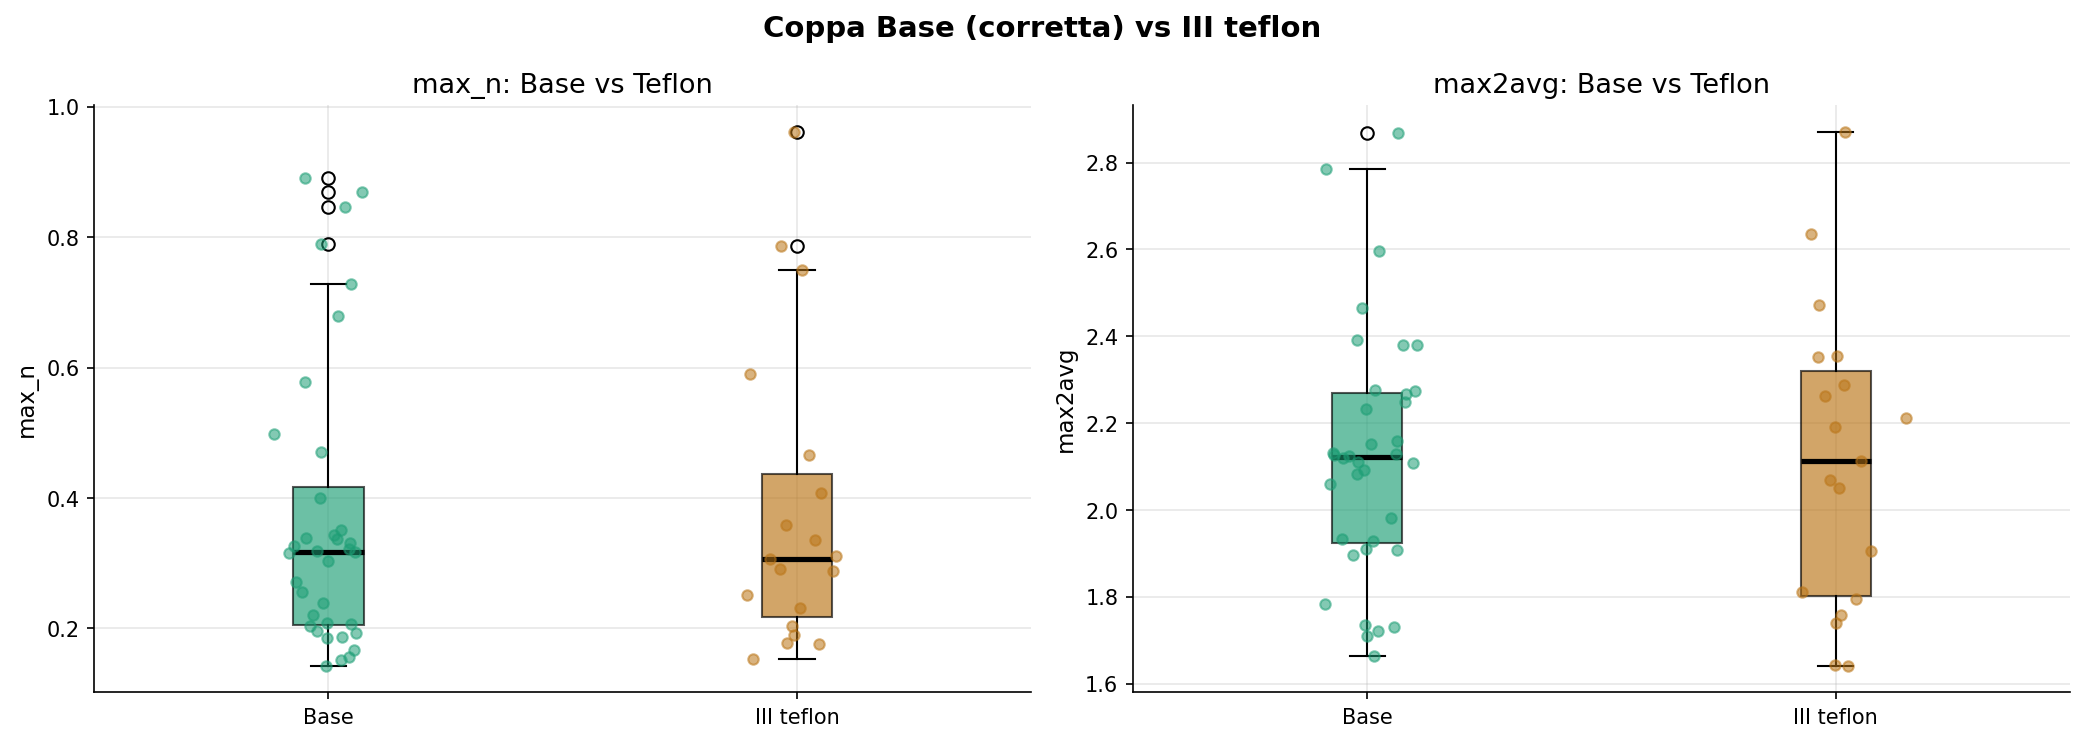

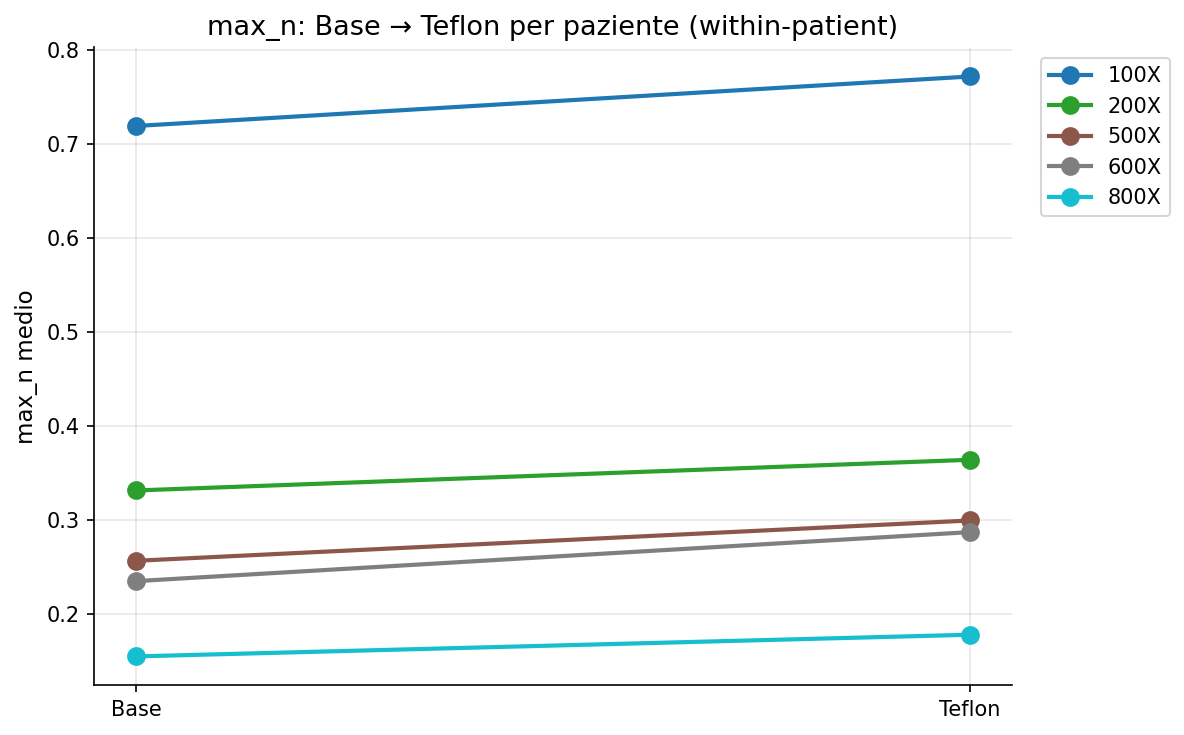

💾 Salvati grafici Base vs Teflon


In [ ]:
# ── GRAFICO: Base vs Teflon ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_i, metric in enumerate(["max_n","max2avg"]):
    data = [base_rows[f"{metric}_mean"].values, teflon_rows[f"{metric}_mean"].values]
    bp = axes[ax_i].boxplot(data, labels=["Base","III teflon"], patch_artist=True,
                             medianprops=dict(color="black", linewidth=2.5))
    for patch, col in zip(bp["boxes"], ["#1D9E75","#BA7517"]):
        patch.set_facecolor(col); patch.set_alpha(0.65)
    for i, d in enumerate(data, 1):
        jitter = np.random.normal(i, 0.05, size=len(d))
        axes[ax_i].scatter(jitter, d, alpha=0.55, s=25,
                           color="#1D9E75" if i==1 else "#BA7517", zorder=3)
    axes[ax_i].set_title(f"{metric}: Base vs Teflon")
    axes[ax_i].set_ylabel(metric)

plt.suptitle("Coppa Base (corretta) vs III teflon", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/base_vs_teflon_boxplot.png")
plt.show()

# Within-patient line plot
fig, ax = plt.subplots(figsize=(8,5))
pat_colors = plt.cm.tab10(np.linspace(0,1,len(pats_both)))
for p, col in zip(pats_both, pat_colors):
    bv = pairs[(pairs["Patient"]==p)&(pairs["Cup_Role"]=="Base")]["max_n_mean"].mean()
    tv = pairs[(pairs["Patient"]==p)&(pairs["Cup"]=="III teflon")]["max_n_mean"].mean()
    ax.plot(["Base","Teflon"], [bv,tv], "o-", color=col, linewidth=2, markersize=8, label=p)
ax.set_title("max_n: Base → Teflon per paziente (within-patient)")
ax.set_ylabel("max_n medio")
ax.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/base_vs_teflon_within_patient.png")
plt.show()
print("💾 Salvati grafici Base vs Teflon")

In [ ]:
# ── Kruskal-Wallis ed effetto coppa (con cup_role corretto per 800X) ───────
print("📊 Kruskal-Wallis — effetto coppa per metrica (dataset corretto):")
kw_rows = []
for m in METRICS:
    groups = [pairs[pairs["Cup"]==cup][f"{m}_mean"].values for cup in cups_order]
    H, p = kruskal(*groups)
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"
    kw_rows.append({"Metrica":m,"H":round(H,2),"p-value":round(p,5),"Sig.":sig})
df_kw = pd.DataFrame(kw_rows)
display(df_kw.style.applymap(
    lambda v: "color:green;font-weight:bold" if v in ["***","**","*"] else "color:gray",
    subset=["Sig."]).set_caption("Kruskal-Wallis: effetto coppa (dataset corretto)"))

print("\n📊 Mann-Whitney pairwise — max_n:")
pw_rows = []
for c1, c2 in combinations(cups_order, 2):
    a = pairs[pairs["Cup"]==c1]["max_n_mean"].values
    b = pairs[pairs["Cup"]==c2]["max_n_mean"].values
    if len(a)>0 and len(b)>0:
        _,p = mannwhitneyu(a,b,alternative="two-sided")
        delta = (np.median(b)-np.median(a))/np.median(a)*100
        pw_rows.append({"Coppa A":c1,"Coppa B":c2,"Δ mediana":f"{delta:+.1f}%","p-value":round(p,4),
                        "Sig.":"***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"})
display(pd.DataFrame(pw_rows))

📊 Kruskal-Wallis — effetto coppa per metrica (dataset corretto):


,Metrica,H,p-value,Sig.
0,max_n,24.120000,0.000020,***
1,max2avg,8.740000,0.032920,*
2,var_p,7.910000,0.047860,*
3,mad_p,6.930000,0.074070,ns
4,var_r,6.240000,0.100610,ns



📊 Mann-Whitney pairwise — max_n:


,Coppa A,Coppa B,Δ mediana,p-value,Sig.
0,I,II,+30.9%,0.0328,*
1,I,III,+118.3%,0.0000,***
2,I,III teflon,+20.2%,0.1643,ns
3,II,III,+66.7%,0.0001,***
4,II,III teflon,-8.1%,0.9922,ns
5,III,III teflon,-44.9%,0.0030,**


## 9. Analisi per paziente e seno

In [ ]:
# ── ETA² — capacità discriminante ────────────────────────────────────────────
eta2_results = []
for m in METRICS:
    groups = [df[df["Patient"]==p][m].values for p in sorted(df["Patient"].unique())]
    grand_mn = df[m].mean()
    SS_between = sum(len(g)*(g.mean()-grand_mn)**2 for g in groups)
    SS_total   = sum((v-grand_mn)**2 for g in groups for v in g)
    eta2 = SS_between/SS_total
    H,p  = kruskal(*groups)
    eta2_results.append({"Metrica":m,"η²":round(eta2,3),"Varianza paziente":f"{eta2*100:.1f}%",
                         "p-value":round(p,5),"Sig.":"***" if p<0.001 else "ns"})
df_eta2 = pd.DataFrame(eta2_results).sort_values("η²", ascending=False)
display(df_eta2.style.background_gradient(subset=["η²"],cmap="Greens",vmin=0,vmax=1)
    .set_caption("Capacità discriminante (dataset corretto)"))
df_eta2.to_csv(f"{OUTPUT_DIR}/eta2_corretto.csv", index=False)

,Metrica,η²,Varianza paziente,p-value,Sig.
0,max_n,0.801000,80.1%,0.000000,***
1,max2avg,0.453000,45.3%,0.000000,***
3,mad_p,0.300000,30.0%,0.000000,***
2,var_p,0.240000,24.0%,0.000000,***
4,var_r,0.199000,19.9%,0.000000,***


In [ ]:
# ── Profilo per paziente e seno ─────────────────────────────────────────────
profile_rows = []
for pat in sorted(df["Patient"].unique()):
    for breast in ["LEFT","RIGHT"]:
        sub = df[(df["Patient"]==pat) & (df["Breast"]==breast)]
        if len(sub)==0: continue
        row = {"Paziente":pat,"Seno":breast,"N":len(sub),"Taglia":sub["Mis_norm"].iloc[0],
               "Età":sub["Eta"].iloc[0]}
        for m in METRICS:
            v = sub[m].values
            row[f"{m}_mean"]=round(v.mean(),4)
            row[f"{m}_cv"]=round(v.std()/v.mean()*100 if v.mean()!=0 else np.nan,2)
        profile_rows.append(row)
df_profile = pd.DataFrame(profile_rows)
print("📋 Profilo per paziente e seno (dataset CORRETTO con flag aggiornati):")
display(df_profile[["Paziente","Seno","Età","Taglia","N","max_n_mean","max_n_cv","max2avg_mean","max2avg_cv"]]
        .style.applymap(color_cv, subset=["max_n_cv","max2avg_cv"]))
df_profile.to_csv(f"{OUTPUT_DIR}/profilo_paziente_seno_corretto.csv", index=False)

📋 Profilo per paziente e seno (dataset CORRETTO con flag aggiornati):


,Paziente,Seno,Età,Taglia,N,max_n_mean,max_n_cv,max2avg_mean,max2avg_cv
0,100X,LEFT,56,Tg.IV,12,0.671300,20.310000,2.333800,15.070000
1,100X,RIGHT,56,Tg.IV,12,0.877600,13.980000,2.545200,12.570000
2,200X,LEFT,46,Tg.II,12,0.375400,13.570000,2.309900,10.430000
3,200X,RIGHT,46,Tg.II,12,0.358100,22.040000,2.257500,8.230000
4,300X,LEFT,68,Tg.IV,6,0.743800,21.550000,2.194000,8.980000
5,300X,RIGHT,68,Tg.IV,6,0.698900,21.530000,2.477200,11.240000
6,400X,LEFT,64,Tg.III,8,0.458700,24.750000,2.219300,10.620000
7,400X,RIGHT,64,Tg.III,8,0.485600,19.570000,2.325800,6.880000
8,500X,LEFT,54,Tg.II,12,0.268000,22.820000,1.971600,10.280000
9,500X,RIGHT,54,Tg.II,12,0.331500,16.970000,2.078200,9.110000


In [ ]:
# ── Asimmetria LEFT/RIGHT ────────────────────────────────────────────────────
asym_rows = []
for pat in sorted(df["Patient"].unique()):
    lrow = df_profile[(df_profile["Paziente"]==pat)&(df_profile["Seno"]=="LEFT")]
    rrow = df_profile[(df_profile["Paziente"]==pat)&(df_profile["Seno"]=="RIGHT")]
    if len(lrow)==0 or len(rrow)==0: continue
    lrow, rrow = lrow.iloc[0], rrow.iloc[0]
    arow = {"Paziente":pat,"Età":lrow["Età"],"Taglia":lrow["Taglia"]}
    for m in METRICS:
        l, r = lrow[f"{m}_mean"], rrow[f"{m}_mean"]
        arow[f"{m}_delta%"] = round((l-r)/((l+r)/2)*100, 2)
    asym_rows.append(arow)
df_asym = pd.DataFrame(asym_rows)
display(df_asym[["Paziente","Età","Taglia","max_n_delta%","max2avg_delta%"]])
df_asym.to_csv(f"{OUTPUT_DIR}/asimmetria_corretto.csv", index=False)

,Paziente,Età,Taglia,max_n_delta%,max2avg_delta%
0,100X,56,Tg.IV,-26.64,-8.67
1,200X,46,Tg.II,4.72,2.29
2,300X,68,Tg.IV,6.22,-12.13
3,400X,64,Tg.III,-5.70,-4.69
4,500X,54,Tg.II,-21.18,-5.26
5,600X,43,Tg.II,1.41,1.16
6,700X,64,Tg.IIIc,12.44,11.40
7,800X,47,Tg.II,-10.80,-0.24
8,900X,53,Tg.II,3.33,1.42


## 10. Analisi dedicata max2avg

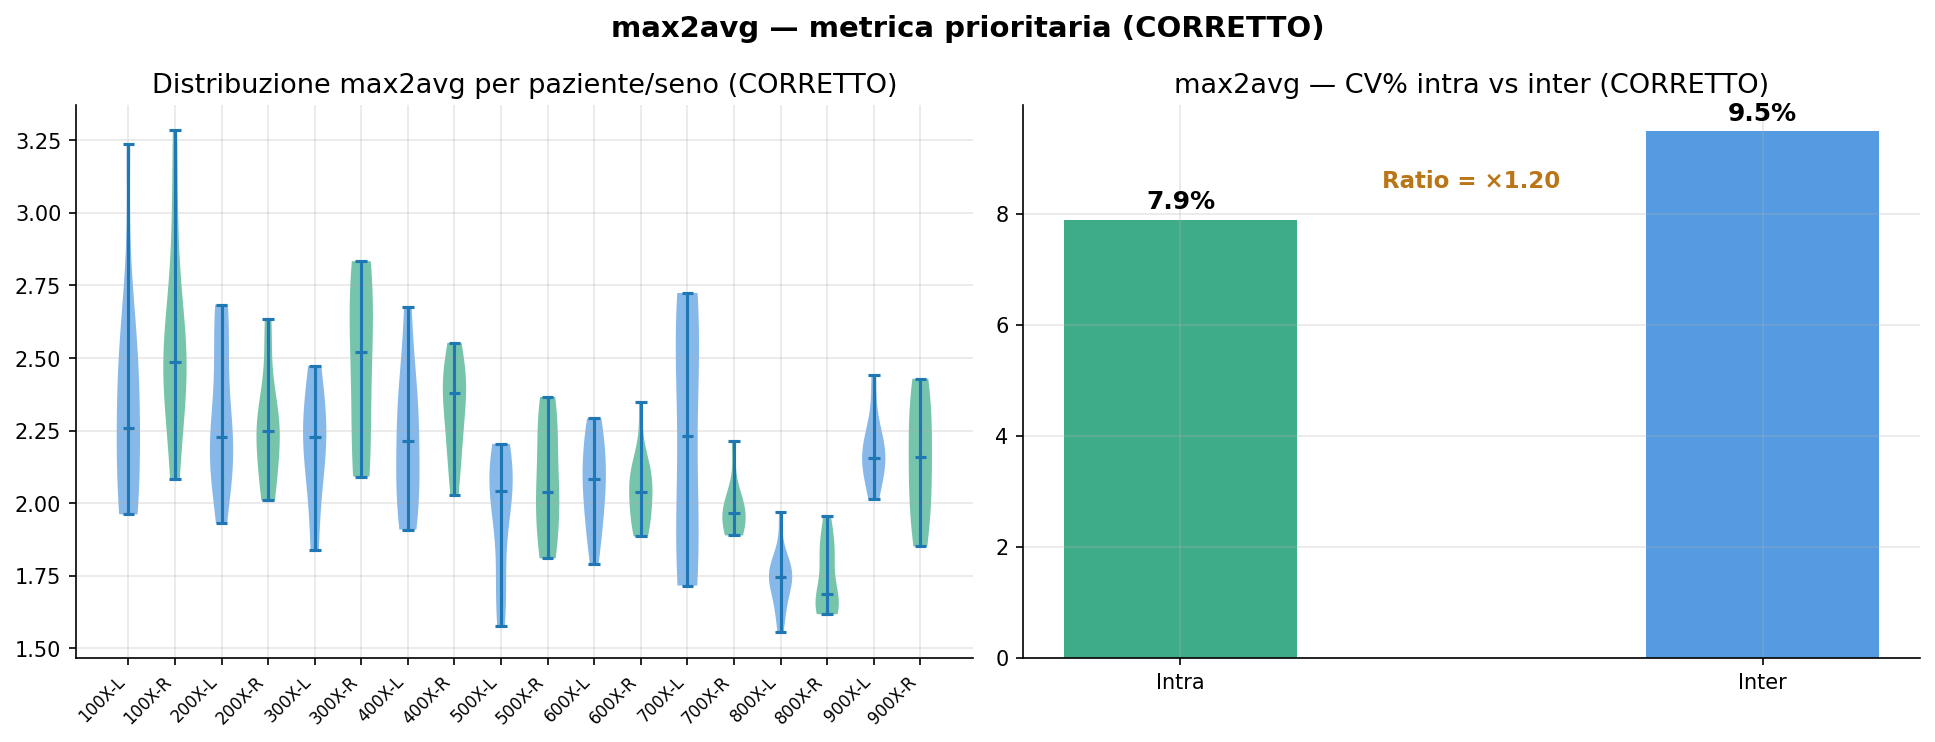

In [ ]:
cv_intra_m2 = pairs["max2avg_cv"].mean()
cv_inter_m2 = inter_clean["max2avg_icv"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13,5))

df["pat_breast"] = df["Patient"].astype(str)+"-"+df["Breast"].str[0]
order_ = [f"{p}-{s}" for p in sorted(df["Patient"].unique()) for s in ["L","R"]]
parts = axes[0].violinplot([df[df["pat_breast"]==pb]["max2avg"].values for pb in order_],
                            positions=range(len(order_)), showmedians=True)
for pc, pb in zip(parts["bodies"], order_):
    pc.set_facecolor("#378ADD" if pb.endswith("-L") else "#1D9E75"); pc.set_alpha(0.6)
axes[0].set_xticks(range(len(order_))); axes[0].set_xticklabels(order_, rotation=45, ha="right", fontsize=8)
axes[0].set_title("Distribuzione max2avg per paziente/seno (CORRETTO)")

bars = axes[1].bar(["Intra","Inter"], [cv_intra_m2, cv_inter_m2], color=["#1D9E75","#378ADD"], alpha=0.85, width=0.4)
axes[1].set_title("max2avg — CV% intra vs inter (CORRETTO)")
for bar, v in zip(bars, [cv_intra_m2, cv_inter_m2]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.2, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=12)
axes[1].text(0.5, 0.85, f"Ratio = ×{cv_inter_m2/cv_intra_m2:.2f}", ha="center",
            transform=axes[1].transAxes, fontsize=11, color="#BA7517", fontweight="bold")

plt.suptitle("max2avg — metrica prioritaria (CORRETTO)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/max2avg_corretto.png")
plt.show()

## 11. Grafici multi-metrica per paziente e seno

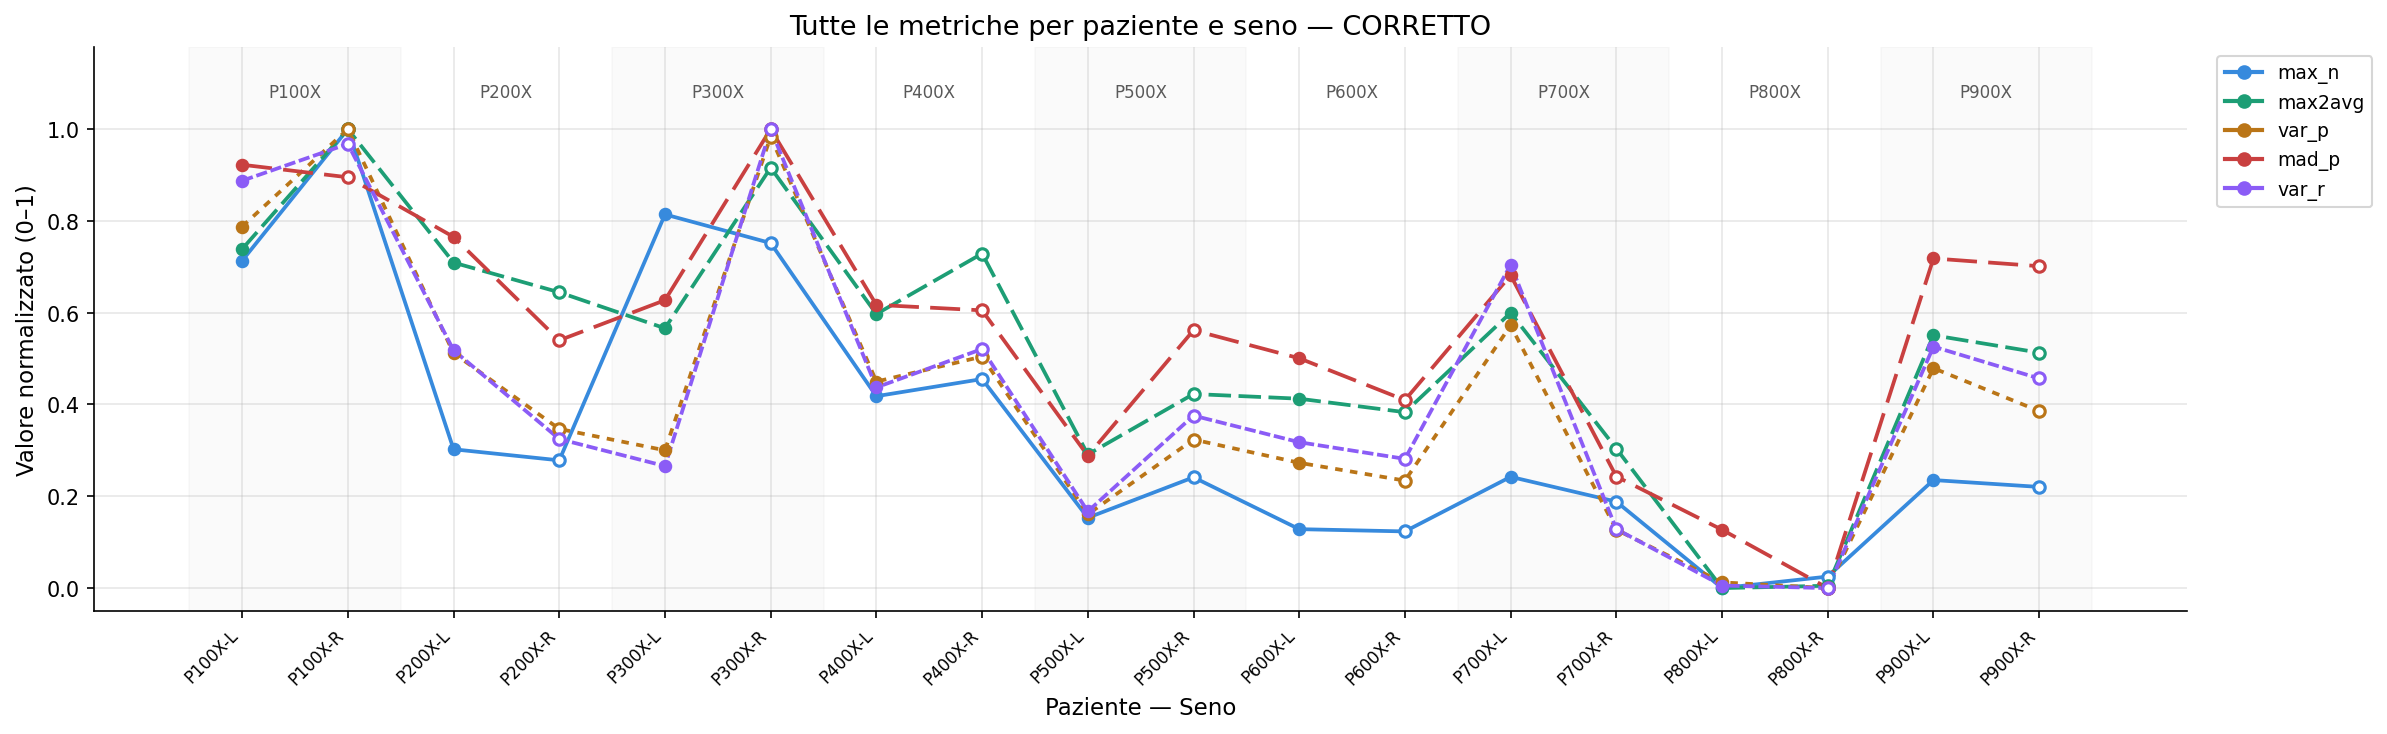

In [ ]:
pb_order = [f"P{p}-{s}" for p in sorted(df["Patient"].unique()) for s in ["LEFT","RIGHT"]]
pb_short = [f"P{p}-{'L' if s=='LEFT' else 'R'}" for p in sorted(df["Patient"].unique()) for s in ["LEFT","RIGHT"]]

colors_m = {"max_n":"#378ADD","max2avg":"#1D9E75","var_p":"#BA7517","mad_p":"#c94040","var_r":"#8b5cf6"}
dashes_m  = {"max_n":(1,0),"max2avg":(6,2),"var_p":(2,2),"mad_p":(8,3),"var_r":(3,1)}

raw_vals={}; norm_vals={}
for m in METRICS:
    vals=[]
    for p in sorted(df["Patient"].unique()):
        for s in ["LEFT","RIGHT"]:
            sub = df[(df["Patient"]==p)&(df["Breast"]==s)]
            vals.append(sub[m].mean() if len(sub)>0 else np.nan)
    raw_vals[m]=np.array(vals)
    mn_,mx_=np.nanmin(vals),np.nanmax(vals)
    norm_vals[m]=np.array([(v-mn_)/(mx_-mn_) if not np.isnan(v) else np.nan for v in vals])

fig, ax = plt.subplots(figsize=(16,5))
x = np.arange(len(pb_order))
for m in METRICS:
    col = colors_m[m]; y = norm_vals[m]
    ax.plot(x, y, "-", color=col, linewidth=1.8, dashes=dashes_m[m], zorder=2)
    x_left  = [xi for xi,pb in zip(x,pb_order) if pb.endswith("-LEFT")]
    y_left  = [y[xi] for xi,pb in zip(x,pb_order) if pb.endswith("-LEFT")]
    x_right = [xi for xi,pb in zip(x,pb_order) if pb.endswith("-RIGHT")]
    y_right = [y[xi] for xi,pb in zip(x,pb_order) if pb.endswith("-RIGHT")]
    ax.scatter(x_left, y_left, s=30, color=col, zorder=3)
    ax.scatter(x_right, y_right, s=30, facecolors="white", edgecolors=col, linewidths=1.5, zorder=3)

for i,p in enumerate(sorted(df["Patient"].unique())):
    ax.axvspan(i*2-0.5,i*2+1.5,alpha=0.04 if i%2==0 else 0.0,color="gray")
    ax.text(i*2+0.5,1.07,f"P{p}",ha="center",fontsize=8,color="#595959")

ax.set_xticks(x); ax.set_xticklabels(pb_short, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Paziente — Seno"); ax.set_ylabel("Valore normalizzato (0–1)")
ax.set_title("Tutte le metriche per paziente e seno — CORRETTO")
ax.set_ylim(-0.05,1.18)

legend_elements = [Line2D([0],[0],color=colors_m[m],linewidth=2,marker="o",markersize=6,label=m) for m in METRICS]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.01,1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/multiplot_normalizzato_corretto.png")
plt.show()

## 12. Export report completo su Google Drive

In [ ]:
output_excel = f"{OUTPUT_DIR}/MAMMOWAVE_Report_CORRETTO.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    df.drop(columns=["pat_breast"], errors="ignore").to_excel(writer, sheet_name="0_Dati_corretti", index=False)
    pairs.to_excel(writer, sheet_name="1_Coppie_intra_CV", index=False)
    df_sem_mdc.to_excel(writer, sheet_name="2_CV_SEM_MDC", index=False)
    df_sw.to_excel(writer, sheet_name="2b_Shapiro_Wilk", index=False)
    inter_clean.to_excel(writer, sheet_name="3a_Inter_dettaglio", index=False)
    df_inter.to_excel(writer, sheet_name="3b_Inter_riepilogo", index=False)
    df_cup.to_excel(writer, sheet_name="4a_Effetto_coppa", index=False)
    df_base_teflon.to_excel(writer, sheet_name="4b_Base_vs_Teflon", index=False)
    df_wp.to_excel(writer, sheet_name="4c_Base_vs_Teflon_WP", index=False)
    df_kw.to_excel(writer, sheet_name="4d_Kruskal_Wallis", index=False)
    df_eta2.to_excel(writer, sheet_name="5_Discriminabilita", index=False)
    df_profile.to_excel(writer, sheet_name="6_Profilo_paziente", index=False)
    df_asym.to_excel(writer, sheet_name="6b_Asimmetria", index=False)
    df_flags.to_excel(writer, sheet_name="7_Flag_dettaglio", index=False)
    df_age.to_excel(writer, sheet_name="8_Eta_corrette", index=False)

print(f"✅ Report Excel CORRETTO salvato: {output_excel}")
import openpyxl
wb = openpyxl.load_workbook(output_excel)
for sh in wb.sheetnames:
    print(f"   • {sh}")

✅ Report Excel CORRETTO salvato: /content/drive/MyDrive/data/rep/output_cor/MAMMOWAVE_Report_CORRETTO.xlsx
   • 0_Dati_corretti
   • 1_Coppie_intra_CV
   • 2_CV_SEM_MDC
   • 2b_Shapiro_Wilk
   • 3a_Inter_dettaglio
   • 3b_Inter_riepilogo
   • 4a_Effetto_coppa
   • 4b_Base_vs_Teflon
   • 4c_Base_vs_Teflon_WP
   • 4d_Kruskal_Wallis
   • 5_Discriminabilita
   • 6_Profilo_paziente
   • 6b_Asimmetria
   • 7_Flag_dettaglio
   • 8_Eta_corrette


In [ ]:
import os
saved = sorted([f for f in os.listdir(OUTPUT_DIR) if f.endswith((".png",".csv",".xlsx"))])
print(f"\n📁 File salvati in {OUTPUT_DIR}: {len(saved)} file totali")
for f in saved:
    size = os.path.getsize(f"{OUTPUT_DIR}/{f}") / 1024
    icon = "📊" if f.endswith(".xlsx") else "🖼️ " if f.endswith(".png") else "📄"
    print(f"  {icon}  {f:<50} {size:>6.1f} KB")


📁 File salvati in /content/drive/MyDrive/data/rep/output_cor: 21 file totali
  📊  MAMMOWAVE_Report_CORRETTO.xlsx                       79.7 KB
  📄  asimmetria_corretto.csv                               0.5 KB
  📄  base_vs_teflon.csv                                    0.3 KB
  🖼️   base_vs_teflon_boxplot.png                           91.9 KB
  📄  base_vs_teflon_within_patient.csv                     0.2 KB
  🖼️   base_vs_teflon_within_patient.png                    52.6 KB
  📄  confronto_completo_vs_pulito_corretto.csv             0.2 KB
  📄  eta2_corretto.csv                                     0.2 KB
  🖼️   eta_vs_metriche_corretto.png                        112.0 KB
  📄  flag_qualita_dettaglio_corretto.csv                   3.2 KB
  🖼️   flag_qualita_pazienti_corretto.png                  103.7 KB
  🖼️   max2avg_corretto.png                                107.0 KB
  🖼️   multiplot_normalizzato_corretto.png                 234.1 KB
  🖼️   passo2_bland_altman_corretto.png             